# Is it the rules, or only which cells are there?

Four questions per PCA: where the FOVs fall, whether the cell counts alone put them
in the same places, whether the split survives dropping the composition-linked cell
types, and which cell types those are.


In [2]:
import os
import sys

sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))            # shared helpers, one level up

import rule_space_helper as rs
# Which mining run: data_helper.RESULT_CSV_PATH, shared by every notebook.
# To read a different one, pass its path to dh.load_results / rs.load below.


In [3]:
# --- Settings for this run. Everything else is left at the helper's default. ---
rs.METRIC            = 'Lift'
rs.POSITIVE_ONLY     = False
rs.RULE_MAX_ITEMS    = 2
rs.NO_SELF           = True
rs.MIN_FOV_THRESHOLD = 0.02
rs.SCORE_COL         = 'Pathological score'

data = rs.load()


Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.
Kept 489672 rules at FDR <= 0.05.
Kept 102887 rules that add information.
Kept 102887 rules (max_items=4, kind=None).


In [4]:
import matplotlib.pyplot as plt
import vis_helper as vh
import rule_space_vis as rsv

def panel(rows, color_by=None, title=None, save=None):
    """Each list is one row of the panel. Short rows leave blank slots."""
    ncols = max(len(r) for r in rows)
    fig, axes = plt.subplots(len(rows), ncols, squeeze=False,
                             figsize=(6 * ncols, 5 * len(rows)))
    for row, scopes in zip(axes, rows):
        for ax, s in zip(row, scopes):
            # what it was built from is the only thing that differs between panels
            rsv.plot_pca_scatter(s.coords, s.variance, color_by=color_by or rs.SCORE_COL,
                                scope=s.built_from, ax=ax)
        for ax in row[len(scopes):]:
            ax.axis('off')
    for ax in axes.flat[1:]:                    # the same colours everywhere - one legend
        if ax.get_legend():
            ax.get_legend().remove()
    fig.tight_layout(rect=(0, 0, 1, 0.98))   # leave the title its own strip
    fig.suptitle(title or rows[0][0].label, fontsize=15, y=0.995)
    vh.save_figure(fig, save)
    plt.show()


# 1. All FOVs, both organs

Only the organs here - the stages are asked per organ below.


In [5]:
all_fovs = rs.run(data,
                   prefix='abund_all', diagnostics=False)


both organs, all stages: 267 FOVs x 220 columns  |  PC1 4.4%  PC2 3.6%


### 1a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


both organs, all stages, cell counts: 267 FOVs x 32 columns  |  PC1 40.6%  PC2 20.5%
both organs, all stages: 267 FOVs x 197 columns  |  PC1 4.8%  PC2 3.7%
both organs, all stages, cell counts without Epithelial: 267 FOVs x 31 columns  |  PC1 36.2%  PC2 20.2%
saved summary_downloads\abund_all_panel.pdf


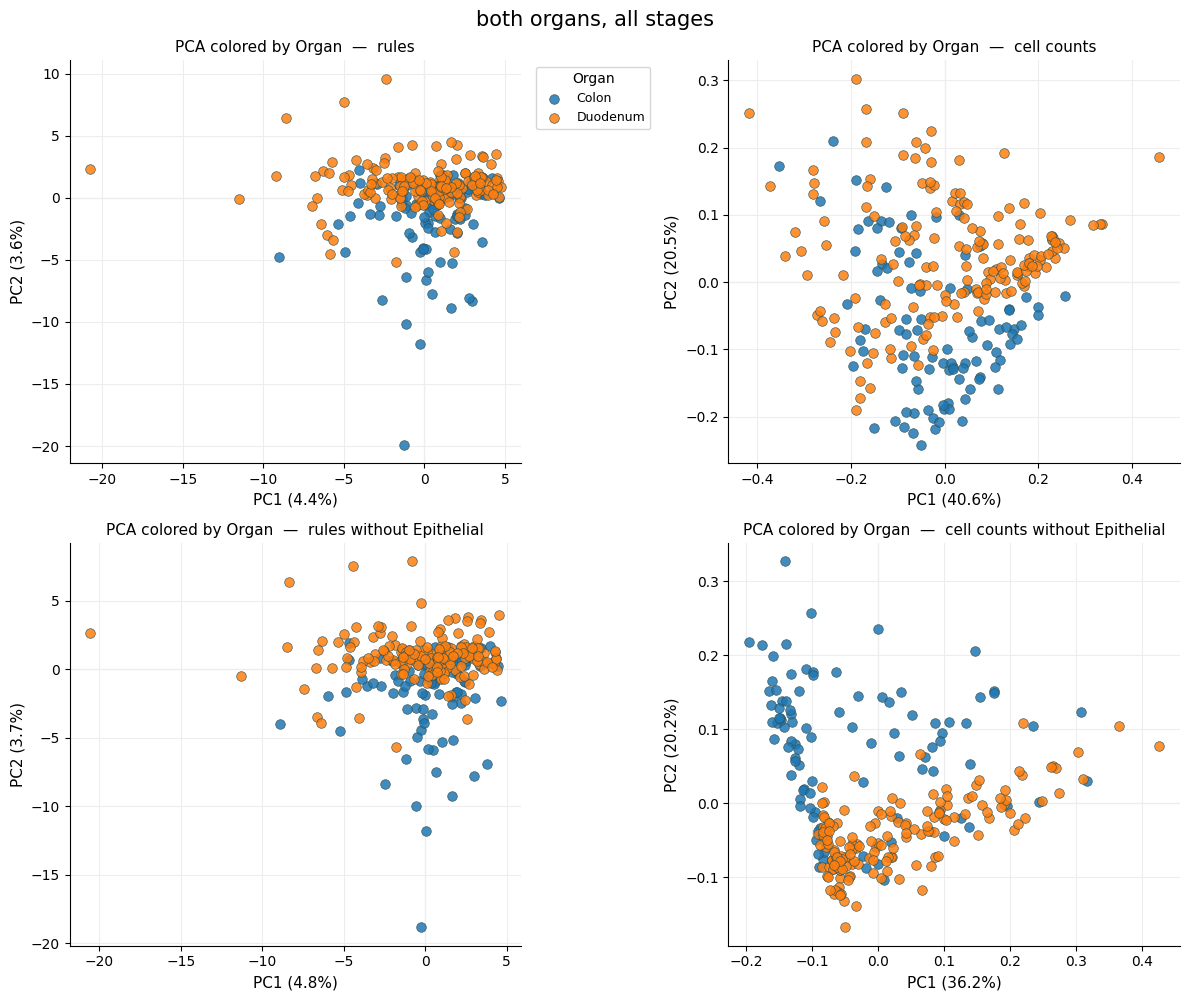

In [6]:
counts  = rs.composition_pca(data, all_fovs)
dropped = rs.leave_one_out(data, all_fovs)   # each row: rules, then cell counts

panel([[all_fovs, counts]] + dropped, color_by='Organ', save='abund_all_panel')


### 1b. Which cell types the components follow


saved summary_downloads\abund_all_abundance_correlation.pdf


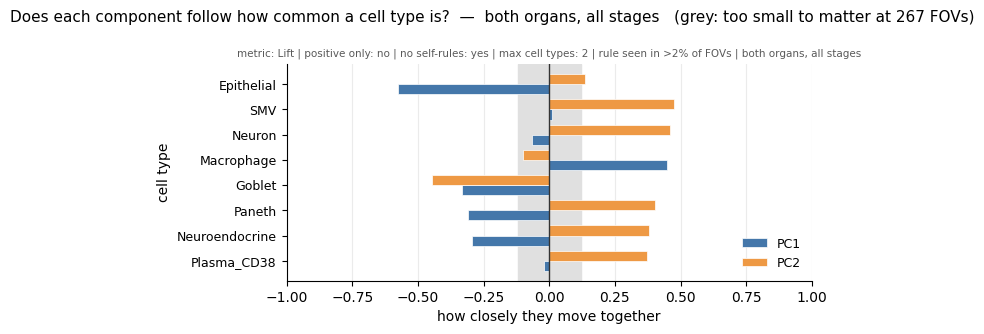

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_all_abundance_top1.pdf


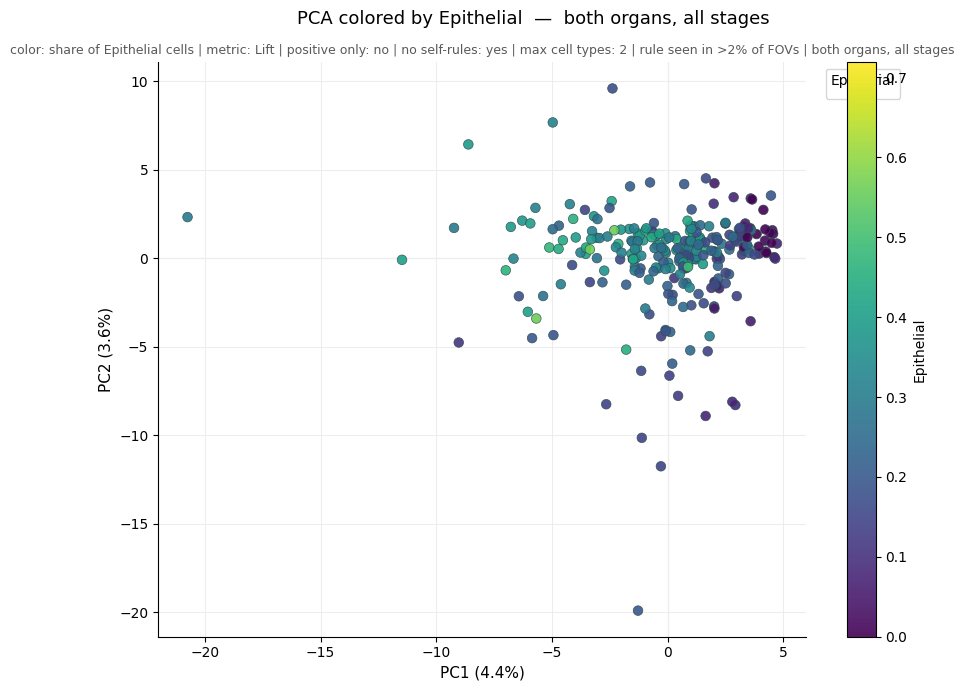

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_all_abundance_top2.pdf


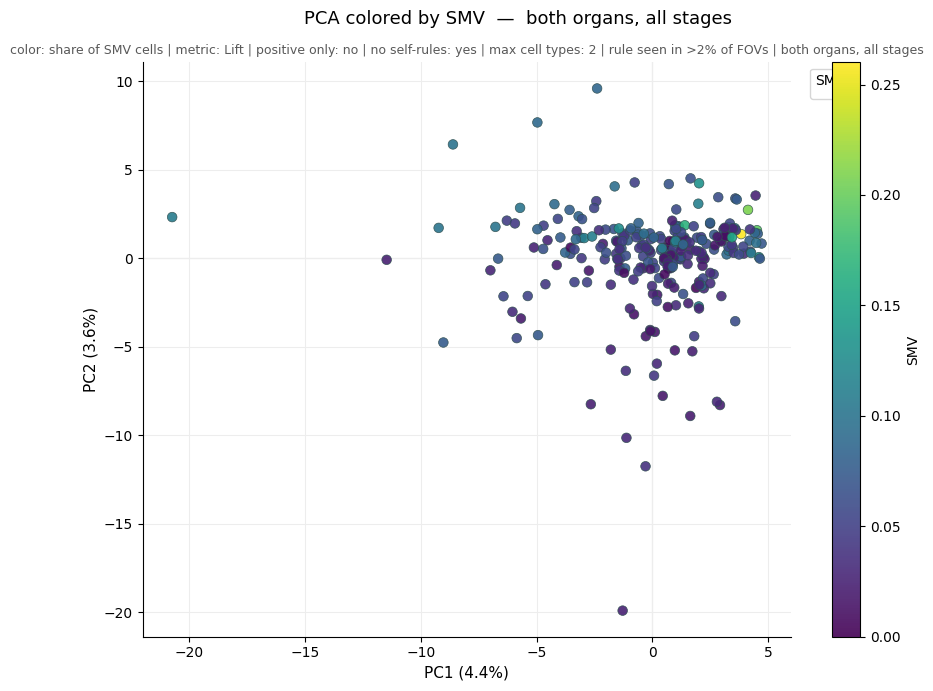

In [7]:
rs.abundance(data, all_fovs, save=True);


# 2. Colon, all stages


In [8]:
colon_all = rs.run(data,
                    organs=['Colon'],
                    prefix='abund_colon', diagnostics=False)


Colon, all stages: 97 FOVs x 218 columns  |  PC1 5.7%  PC2 4.9%


### 2a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Colon, all stages, cell counts: 97 FOVs x 32 columns  |  PC1 38.1%  PC2 25.2%
Colon, all stages: 97 FOVs x 181 columns  |  PC1 5.8%  PC2 5.6%
Colon, all stages, cell counts without CD4T: 97 FOVs x 31 columns  |  PC1 39.4%  PC2 26.1%
Colon, all stages: 97 FOVs x 198 columns  |  PC1 5.9%  PC2 5.2%
Colon, all stages, cell counts without Epithelial: 97 FOVs x 31 columns  |  PC1 43.7%  PC2 27.5%
Colon, all stages: 97 FOVs x 205 columns  |  PC1 5.5%  PC2 5.2%
Colon, all stages, cell counts without Treg: 97 FOVs x 31 columns  |  PC1 38.4%  PC2 25.4%
Colon, all stages: 97 FOVs x 185 columns  |  PC1 5.7%  PC2 5.4%
Colon, all stages, cell counts without Muscle: 97 FOVs x 31 columns  |  PC1 35.1%  PC2 30.8%


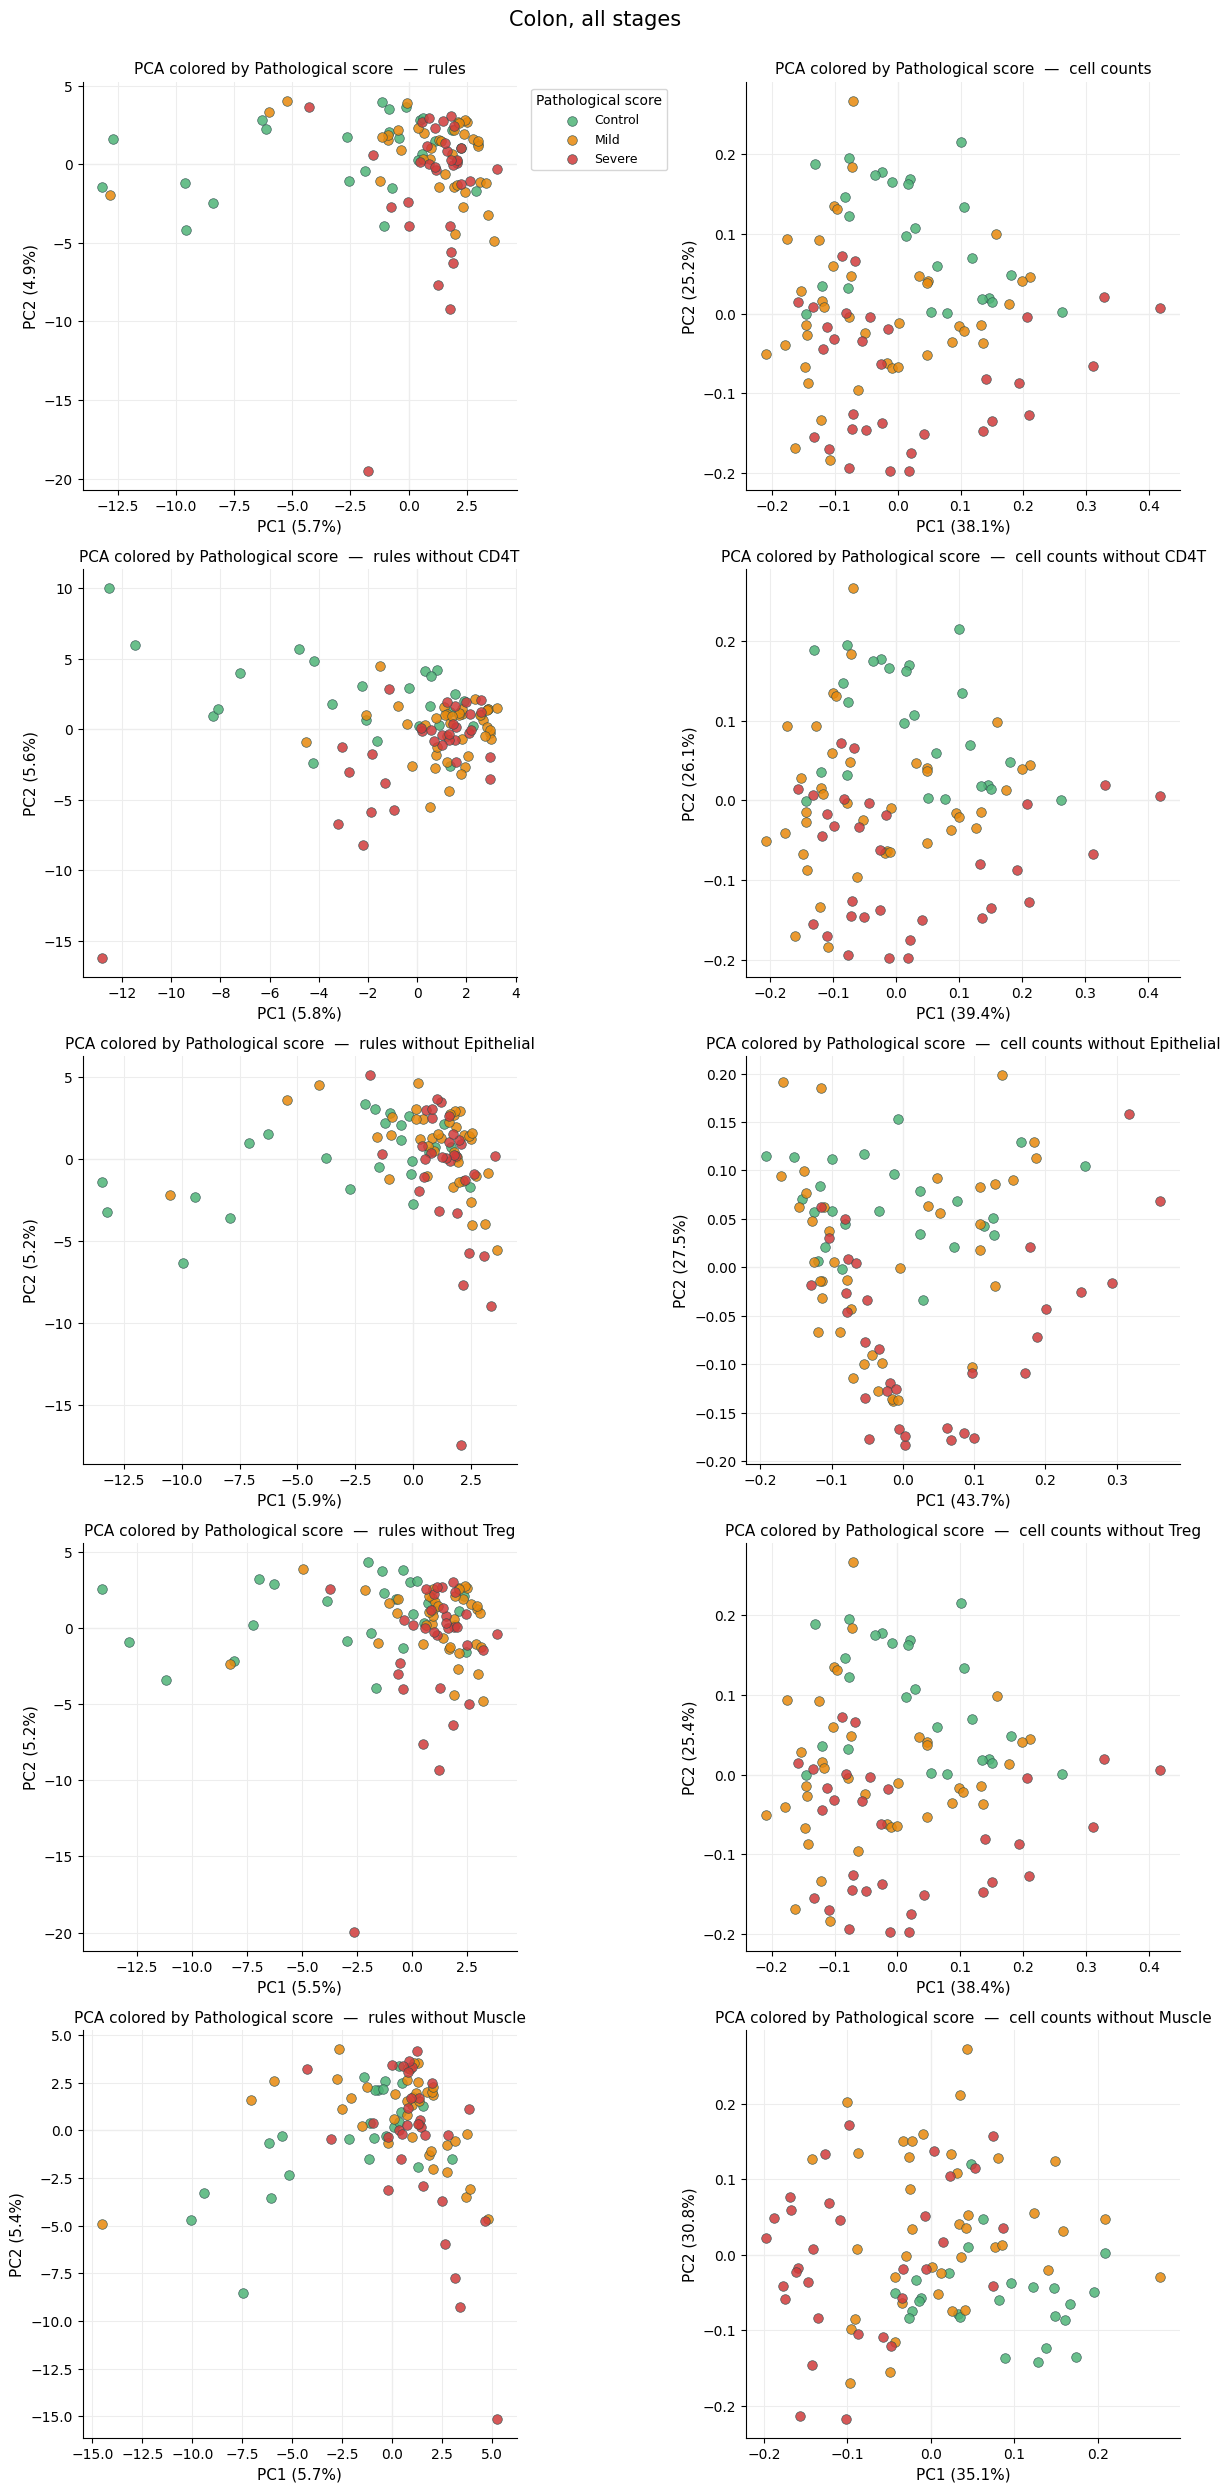

In [9]:
counts  = rs.composition_pca(data, colon_all)
dropped = rs.leave_one_out(data, colon_all)   # each row: rules, then cell counts

panel([[colon_all, counts]] + dropped, save=None)


### 2b. Which cell types the components follow


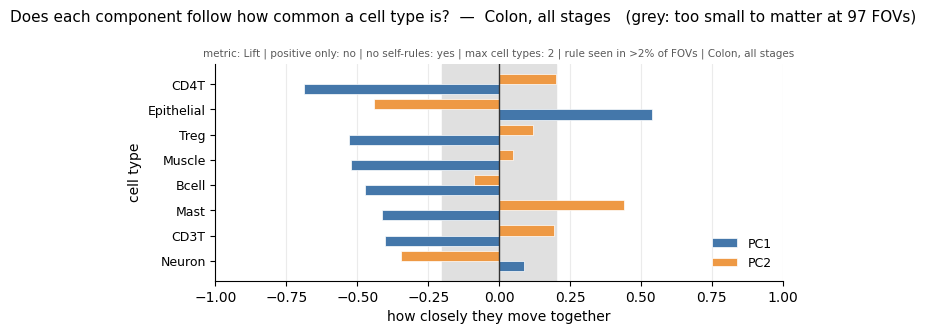

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


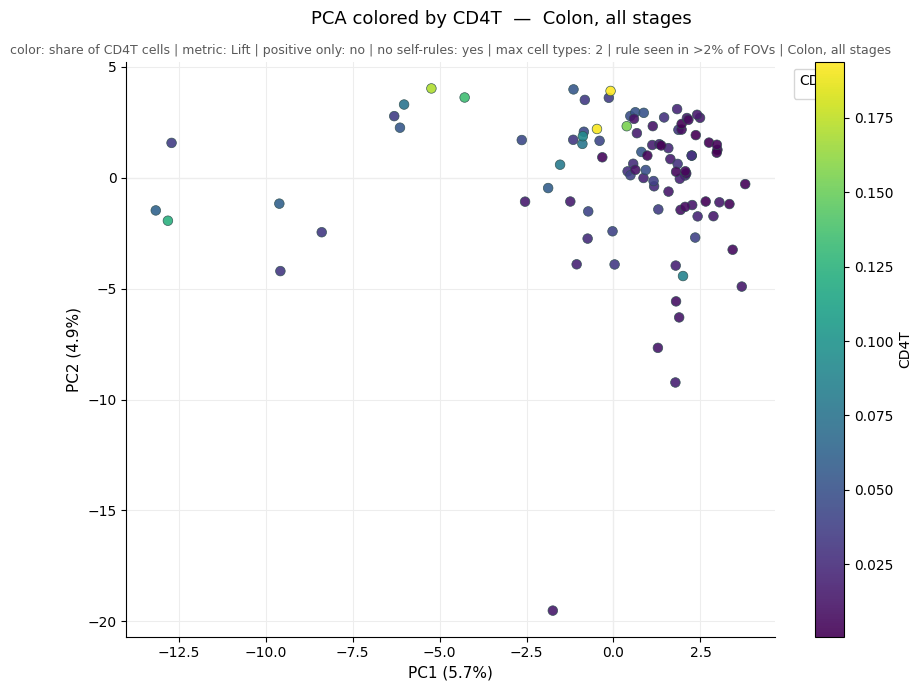

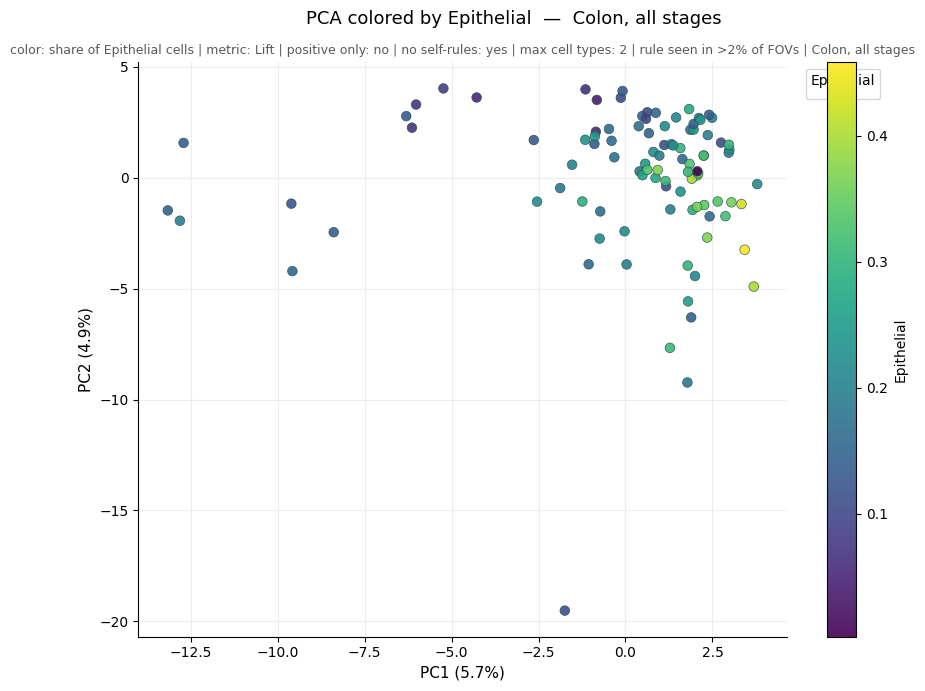

In [10]:
rs.abundance(data, colon_all, save=False);


# 3. Duodenum, all stages


In [11]:
duodenum_all = rs.run(data,
                       organs=['Duodenum'],
                       prefix='abund_duodenum', diagnostics=False)


Duodenum, all stages: 170 FOVs x 226 columns  |  PC1 5.3%  PC2 3.5%


### 3a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Duodenum, all stages, cell counts: 170 FOVs x 32 columns  |  PC1 51.4%  PC2 19.8%
Duodenum, all stages: 170 FOVs x 203 columns  |  PC1 5.8%  PC2 3.5%
Duodenum, all stages, cell counts without Epithelial: 170 FOVs x 31 columns  |  PC1 41.5%  PC2 15.6%
Duodenum, all stages: 170 FOVs x 196 columns  |  PC1 4.0%  PC2 3.7%
Duodenum, all stages, cell counts without Goblet: 170 FOVs x 31 columns  |  PC1 51.4%  PC2 20.1%
Duodenum, all stages: 169 FOVs x 196 columns  |  PC1 4.6%  PC2 3.6%
Duodenum, all stages, cell counts without Macrophage: 170 FOVs x 31 columns  |  PC1 53.3%  PC2 19.7%


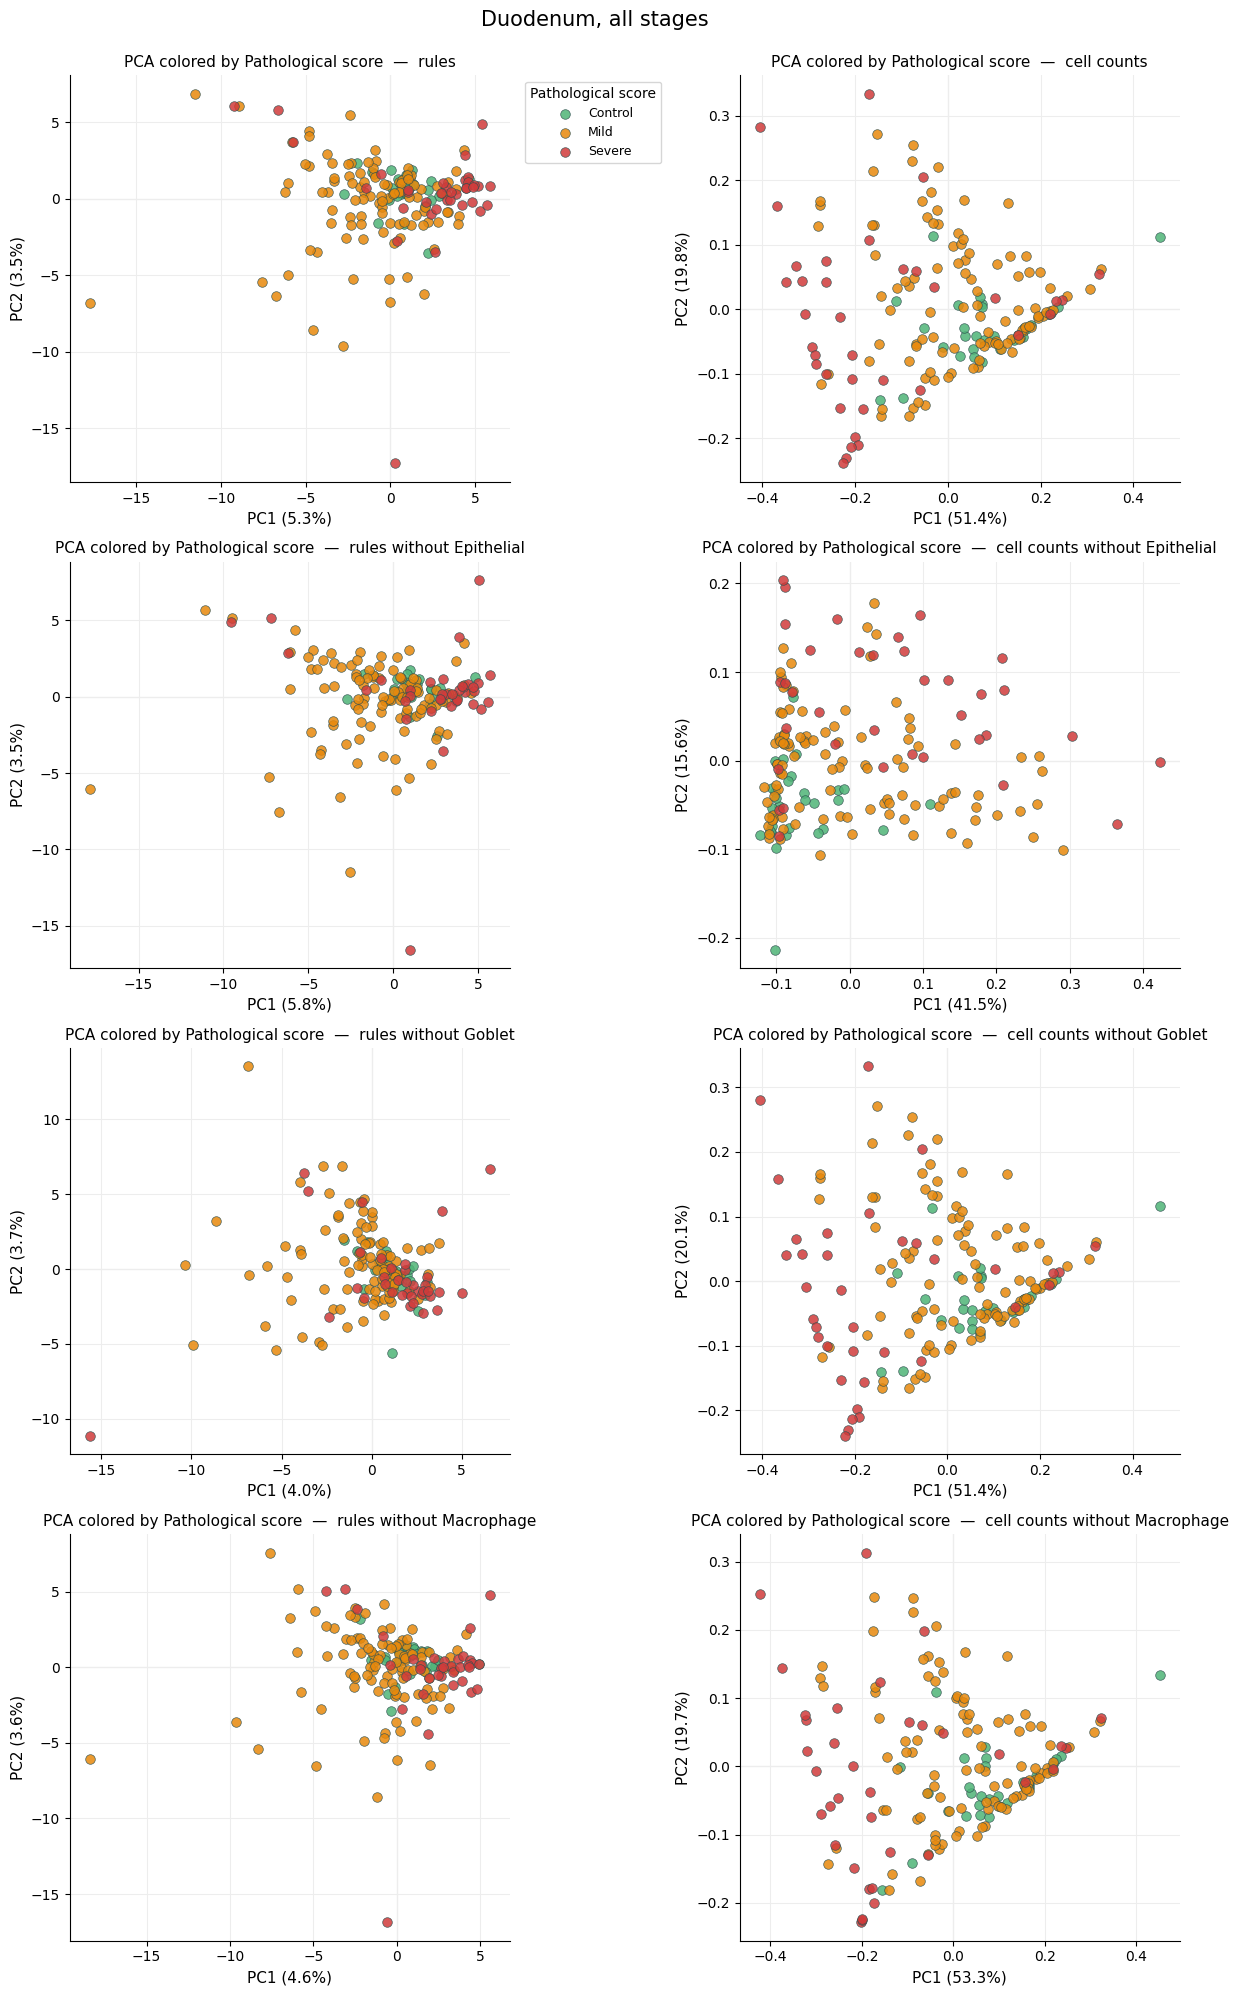

In [12]:
counts  = rs.composition_pca(data, duodenum_all)
dropped = rs.leave_one_out(data, duodenum_all)   # each row: rules, then cell counts

panel([[duodenum_all, counts]] + dropped, save=None)


### 3b. Which cell types the components follow


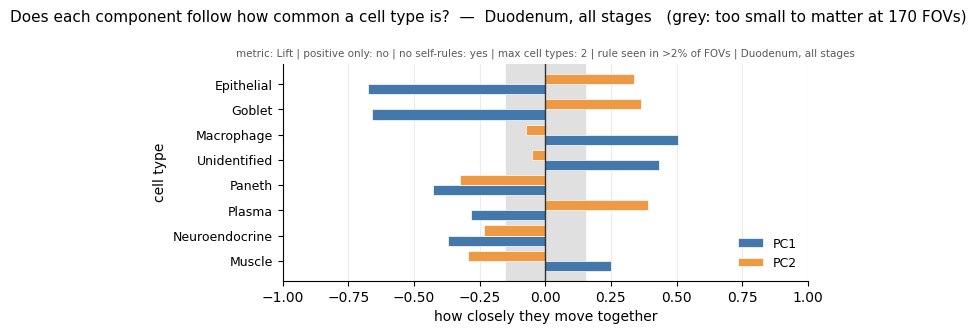

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


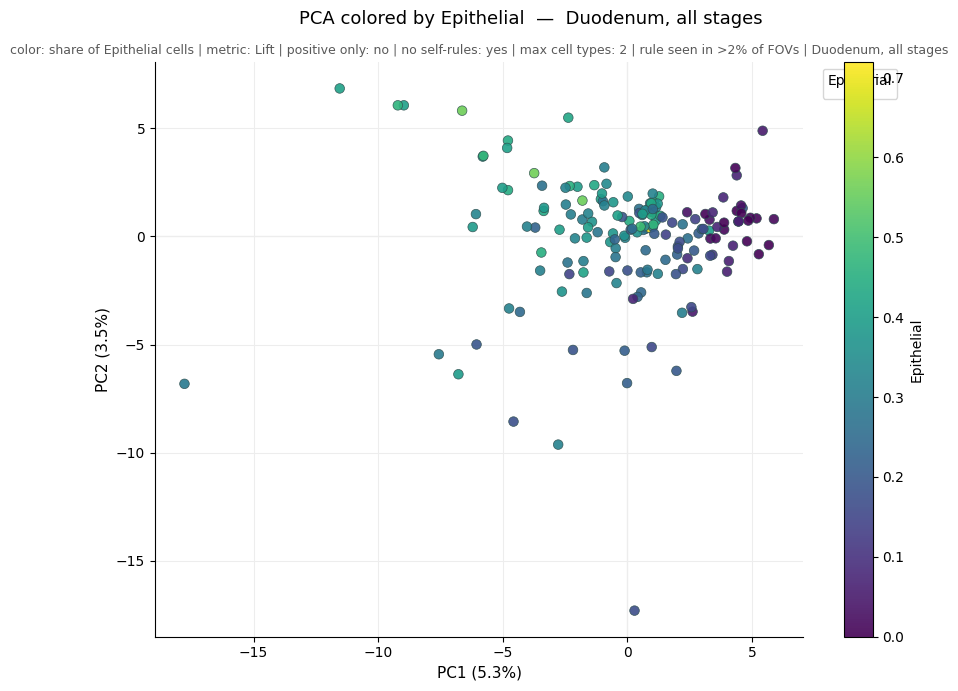

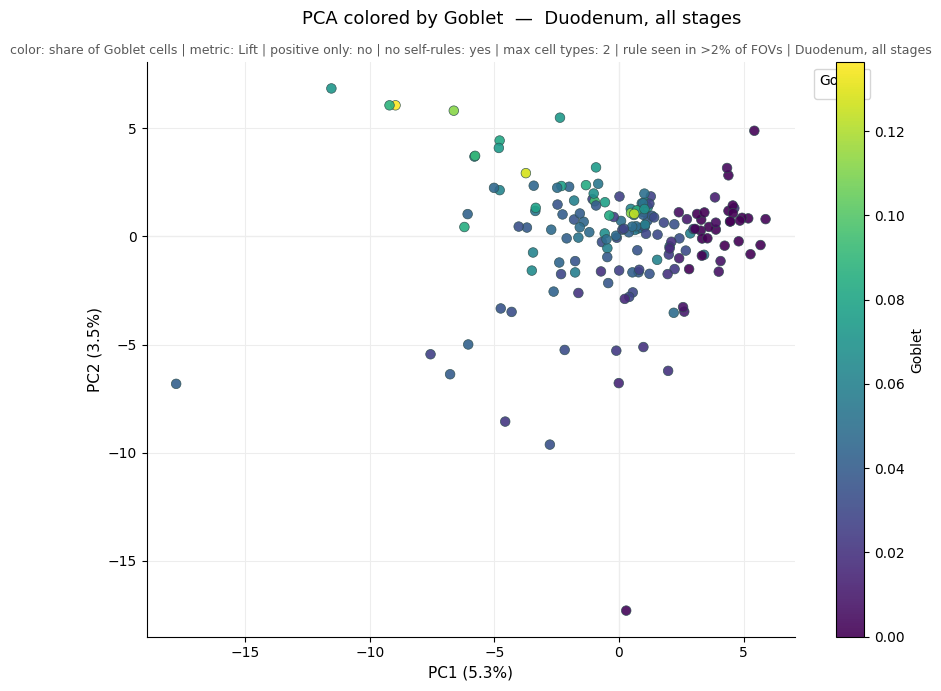

In [13]:
rs.abundance(data, duodenum_all, save=False);


# 4. Colon, Control vs Severe


In [14]:
cs_colon = rs.run(data,
                   stages=['Control', 'Severe'], organs=['Colon'],
                   prefix='abund_cs_colon', diagnostics=False)


Colon, Control vs Severe: 57 FOVs x 177 columns  |  PC1 8.0%  PC2 7.0%


### 4a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Colon, Control vs Severe, cell counts: 57 FOVs x 32 columns  |  PC1 41.3%  PC2 30.7%
Colon, Control vs Severe: 57 FOVs x 152 columns  |  PC1 8.3%  PC2 7.0%
Colon, Control vs Severe, cell counts without CD4T: 57 FOVs x 31 columns  |  PC1 41.7%  PC2 31.0%
Colon, Control vs Severe: 57 FOVs x 151 columns  |  PC1 8.5%  PC2 7.8%
Colon, Control vs Severe, cell counts without Plasma: 57 FOVs x 31 columns  |  PC1 43.5%  PC2 31.2%
Colon, Control vs Severe: 57 FOVs x 164 columns  |  PC1 8.4%  PC2 7.1%
Colon, Control vs Severe, cell counts without Epithelial: 57 FOVs x 31 columns  |  PC1 48.9%  PC2 28.4%
Colon, Control vs Severe: 57 FOVs x 167 columns  |  PC1 8.1%  PC2 7.3%
Colon, Control vs Severe, cell counts without Mast: 57 FOVs x 31 columns  |  PC1 41.3%  PC2 30.7%
saved summary_downloads\abund_cs_colon_panel.pdf


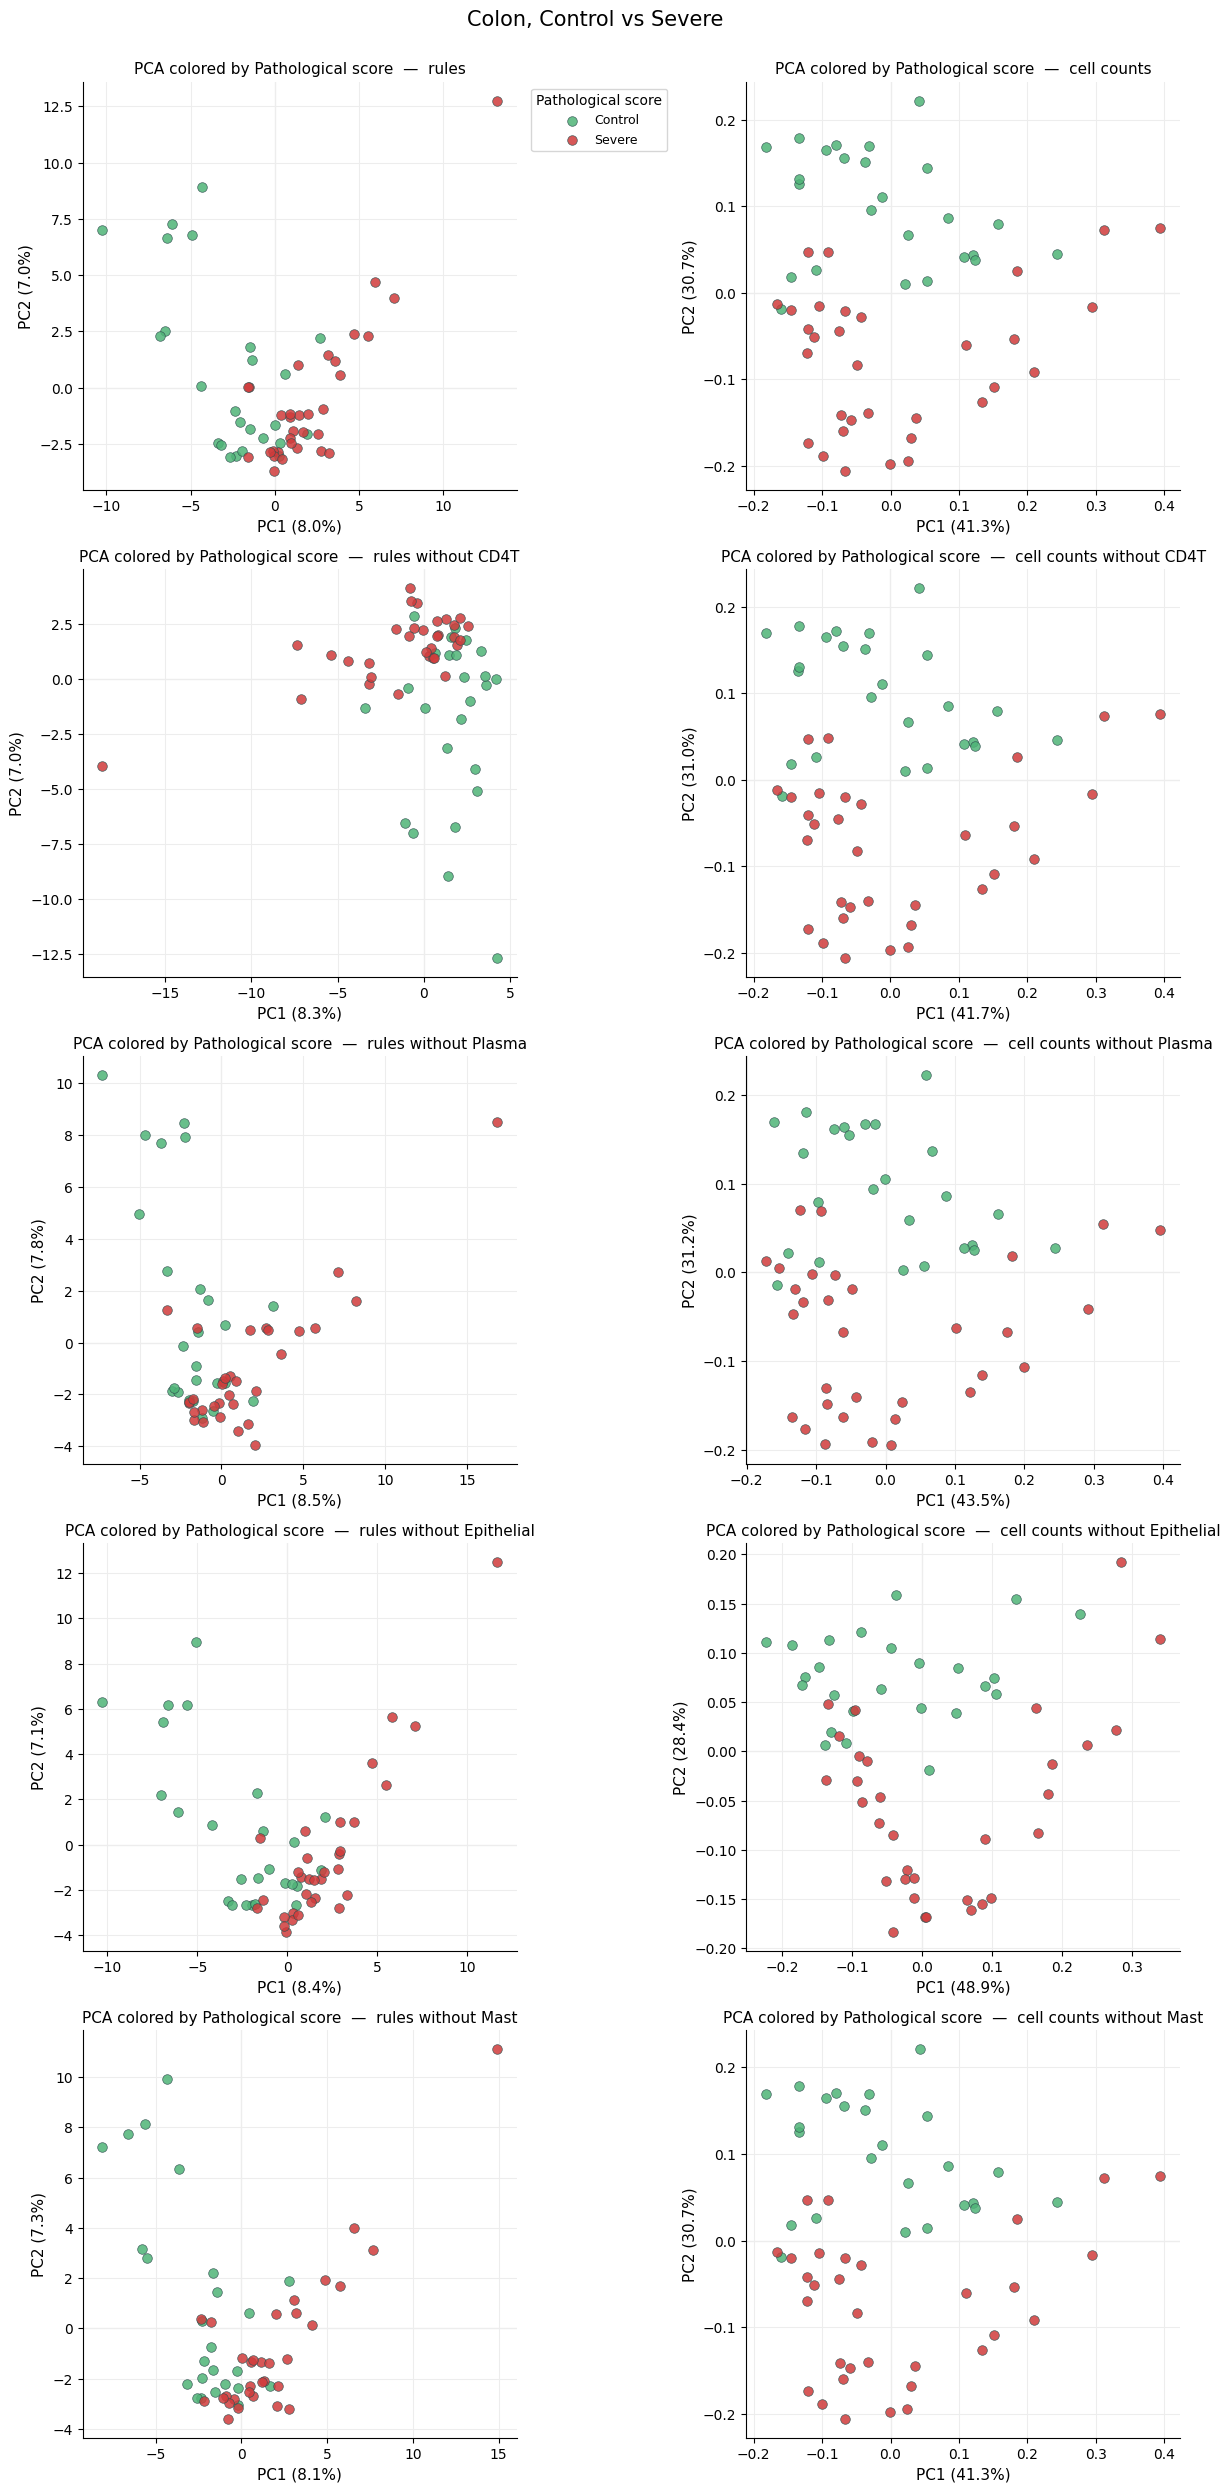

In [15]:
counts  = rs.composition_pca(data, cs_colon)
dropped = rs.leave_one_out(data, cs_colon)   # each row: rules, then cell counts

panel([[cs_colon, counts]] + dropped, save='abund_cs_colon_panel')


### 4b. Which cell types the components follow


saved summary_downloads\abund_cs_colon_abundance_correlation.pdf


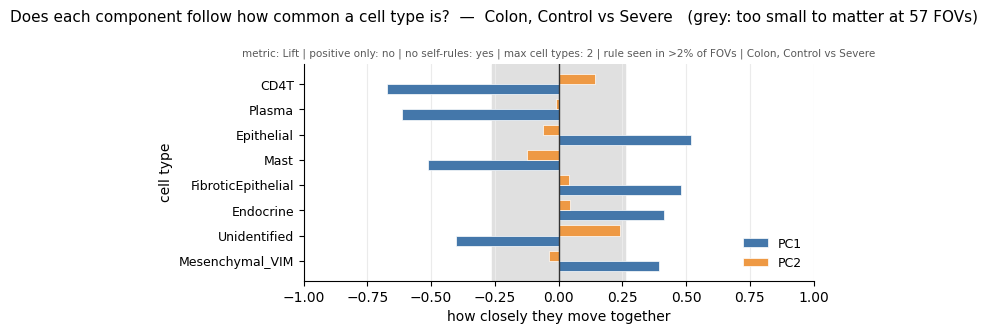

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_cs_colon_abundance_top1.pdf


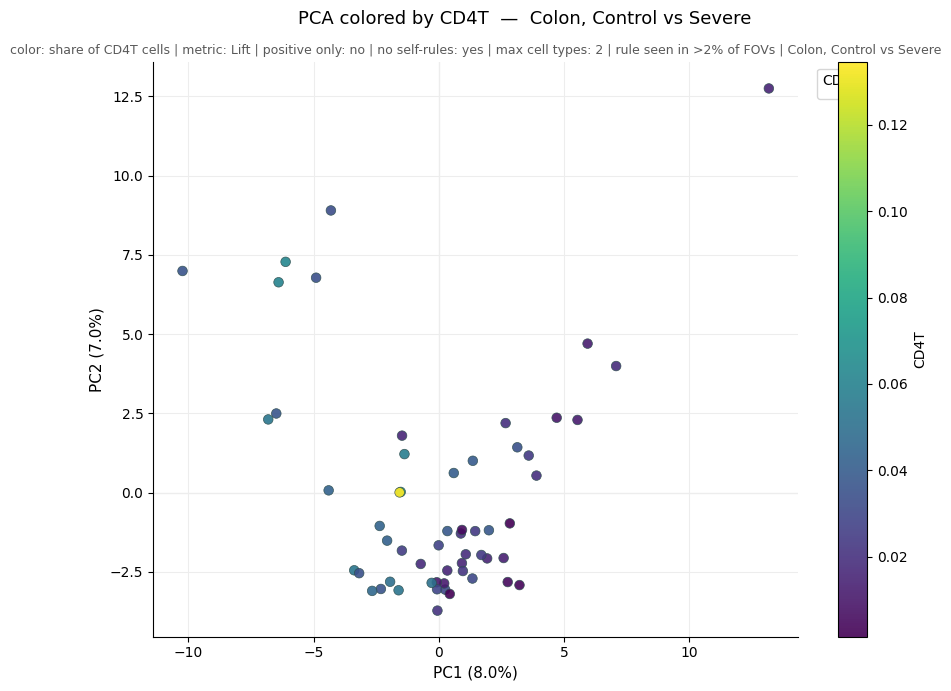

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_cs_colon_abundance_top2.pdf


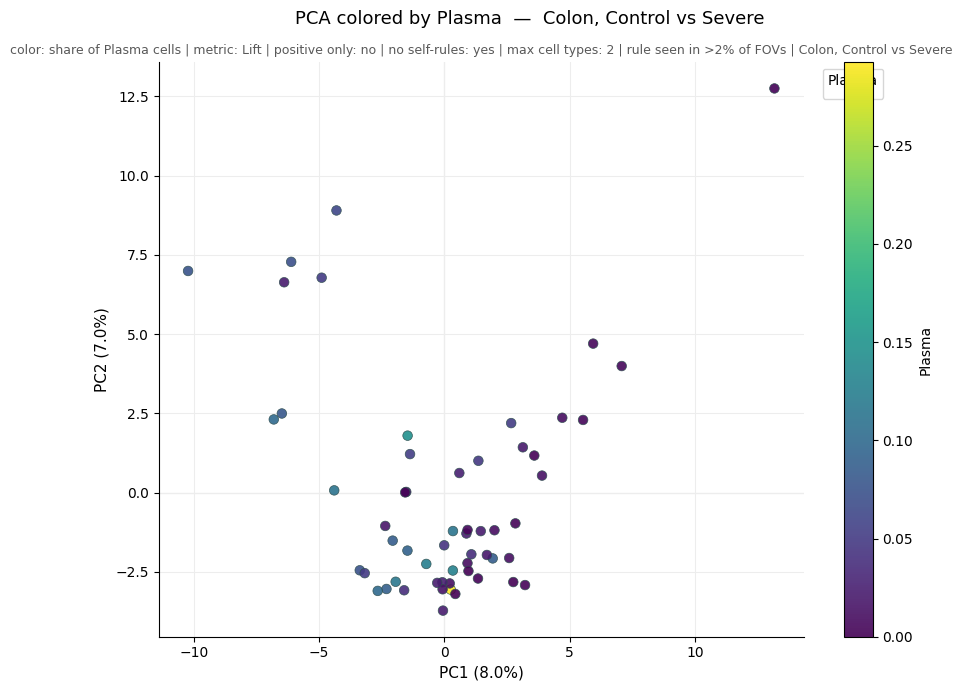

In [16]:
rs.abundance(data, cs_colon, save=True);


# 5. Duodenum, Control vs Severe


In [17]:
cs_duodenum = rs.run(data,
                      stages=['Control', 'Severe'], organs=['Duodenum'],
                      prefix='abund_cs_duodenum', diagnostics=False)


Duodenum, Control vs Severe: 67 FOVs x 227 columns  |  PC1 7.6%  PC2 5.6%


### 5a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Duodenum, Control vs Severe, cell counts: 67 FOVs x 32 columns  |  PC1 57.0%  PC2 16.2%
Duodenum, Control vs Severe: 67 FOVs x 209 columns  |  PC1 8.1%  PC2 5.7%
Duodenum, Control vs Severe, cell counts without Epithelial: 67 FOVs x 31 columns  |  PC1 41.7%  PC2 18.7%
Duodenum, Control vs Severe: 67 FOVs x 199 columns  |  PC1 6.5%  PC2 5.4%
Duodenum, Control vs Severe, cell counts without Goblet: 67 FOVs x 31 columns  |  PC1 56.9%  PC2 16.3%
Duodenum, Control vs Severe: 67 FOVs x 226 columns  |  PC1 7.6%  PC2 5.6%
Duodenum, Control vs Severe, cell counts without FibroticEpithelial: 67 FOVs x 31 columns  |  PC1 57.0%  PC2 16.2%
Duodenum, Control vs Severe: 67 FOVs x 190 columns  |  PC1 8.4%  PC2 6.0%
Duodenum, Control vs Severe, cell counts without Muscle: 67 FOVs x 31 columns  |  PC1 63.9%  PC2 13.1%
Duodenum, Control vs Severe: 67 FOVs x 217 columns  |  PC1 7.7%  PC2 5.3%
Duodenum, Control vs Severe, cell counts without Mesenchymal_VIM: 67 FOVs x 31 columns  |  PC1 57.1%  PC2 16.2%
Du

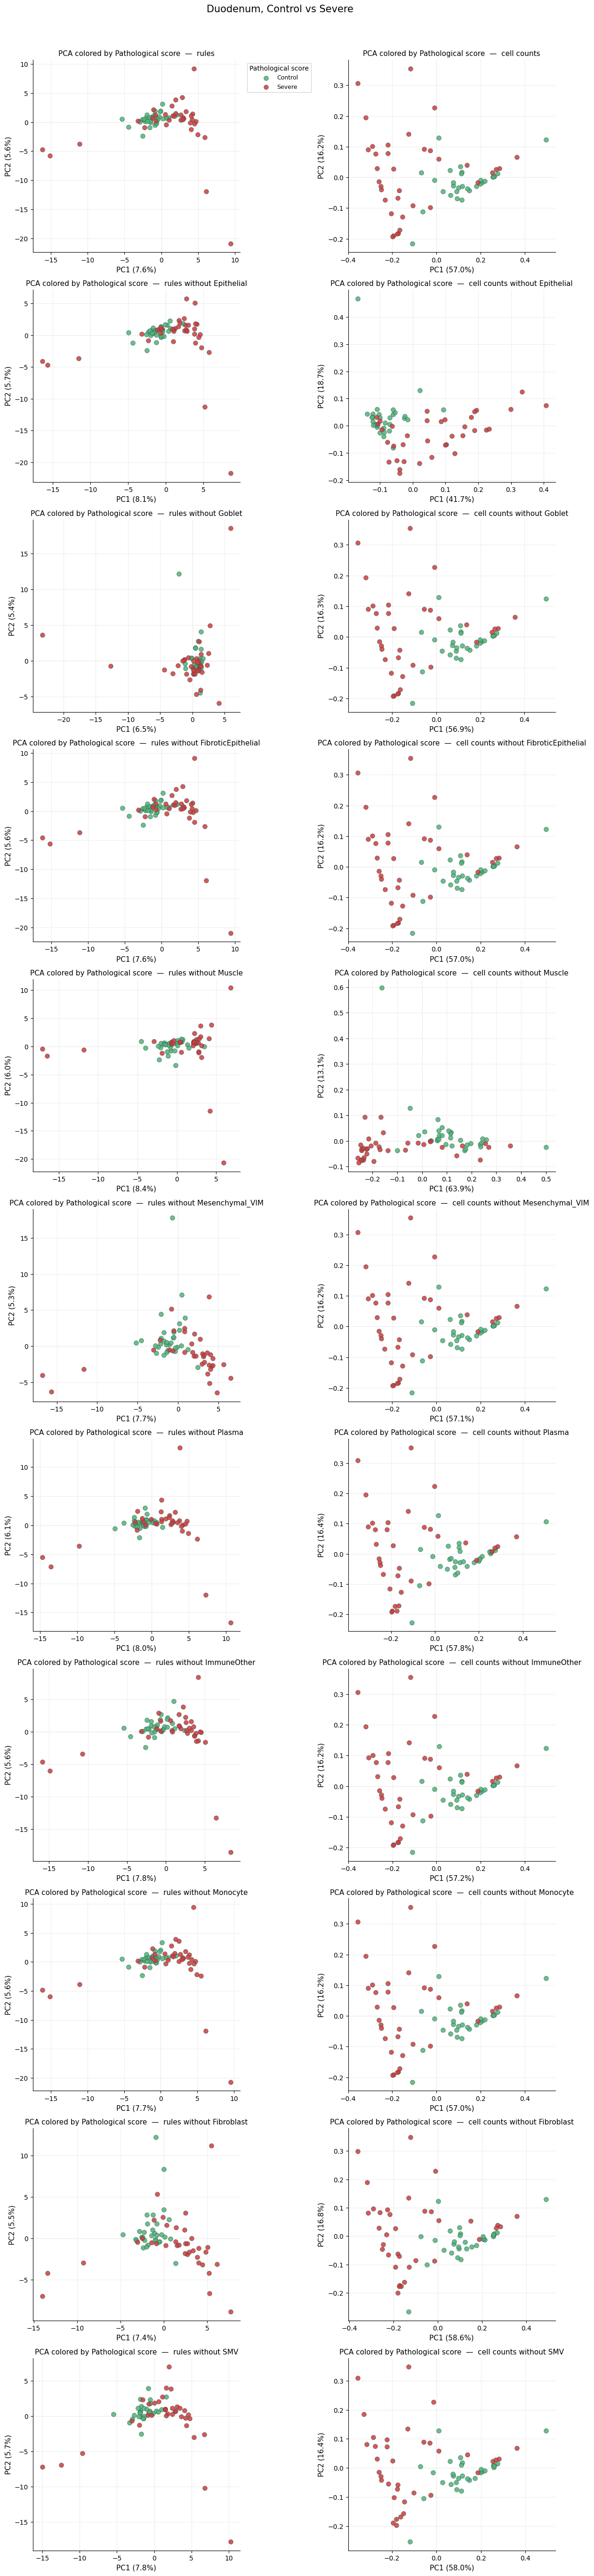

In [18]:
counts  = rs.composition_pca(data, cs_duodenum)
dropped = rs.leave_one_out(data, cs_duodenum)   # each row: rules, then cell counts

panel([[cs_duodenum, counts]] + dropped, save='abund_cs_duodenum_panel')


### 5b. Which cell types the components follow


saved summary_downloads\abund_cs_duodenum_abundance_correlation.pdf


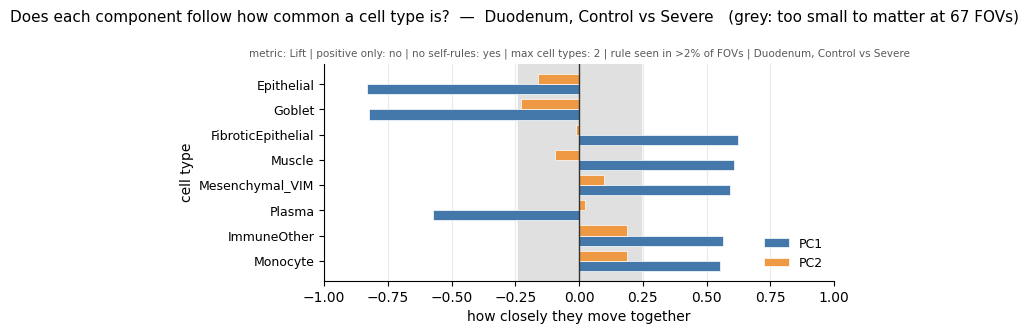

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_cs_duodenum_abundance_top1.pdf


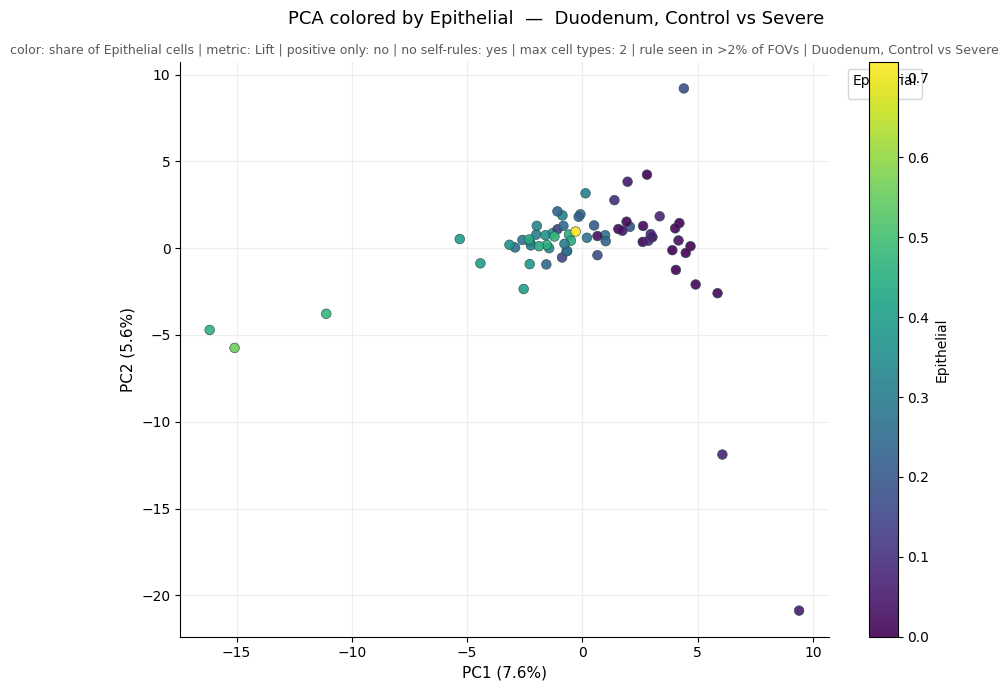

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_cs_duodenum_abundance_top2.pdf


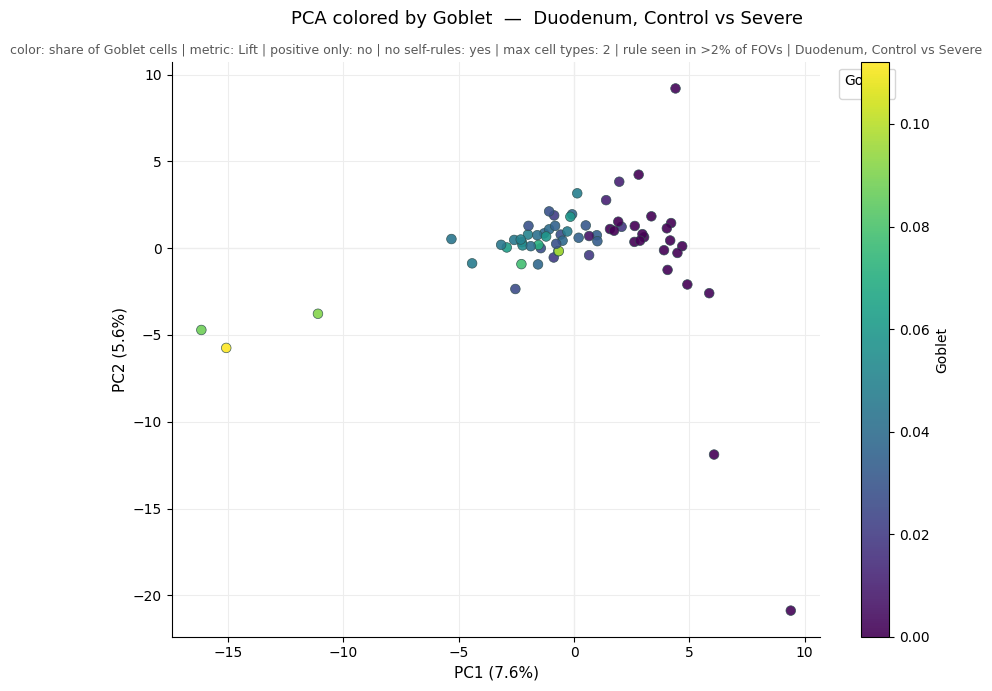

In [19]:
rs.abundance(data, cs_duodenum, save=True);


# 6. Colon, Mild vs Severe


In [20]:
ms_colon = rs.run(data,
                   stages=['Mild', 'Severe'], organs=['Colon'],
                   prefix='abund_ms_colon', diagnostics=False)


Colon, Mild vs Severe: 72 FOVs x 178 columns  |  PC1 6.8%  PC2 6.6%


### 6a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Colon, Mild vs Severe, cell counts: 72 FOVs x 32 columns  |  PC1 41.0%  PC2 23.1%
Colon, Mild vs Severe: 72 FOVs x 146 columns  |  PC1 7.8%  PC2 6.5%
Colon, Mild vs Severe, cell counts without CD4T: 72 FOVs x 31 columns  |  PC1 42.8%  PC2 23.8%


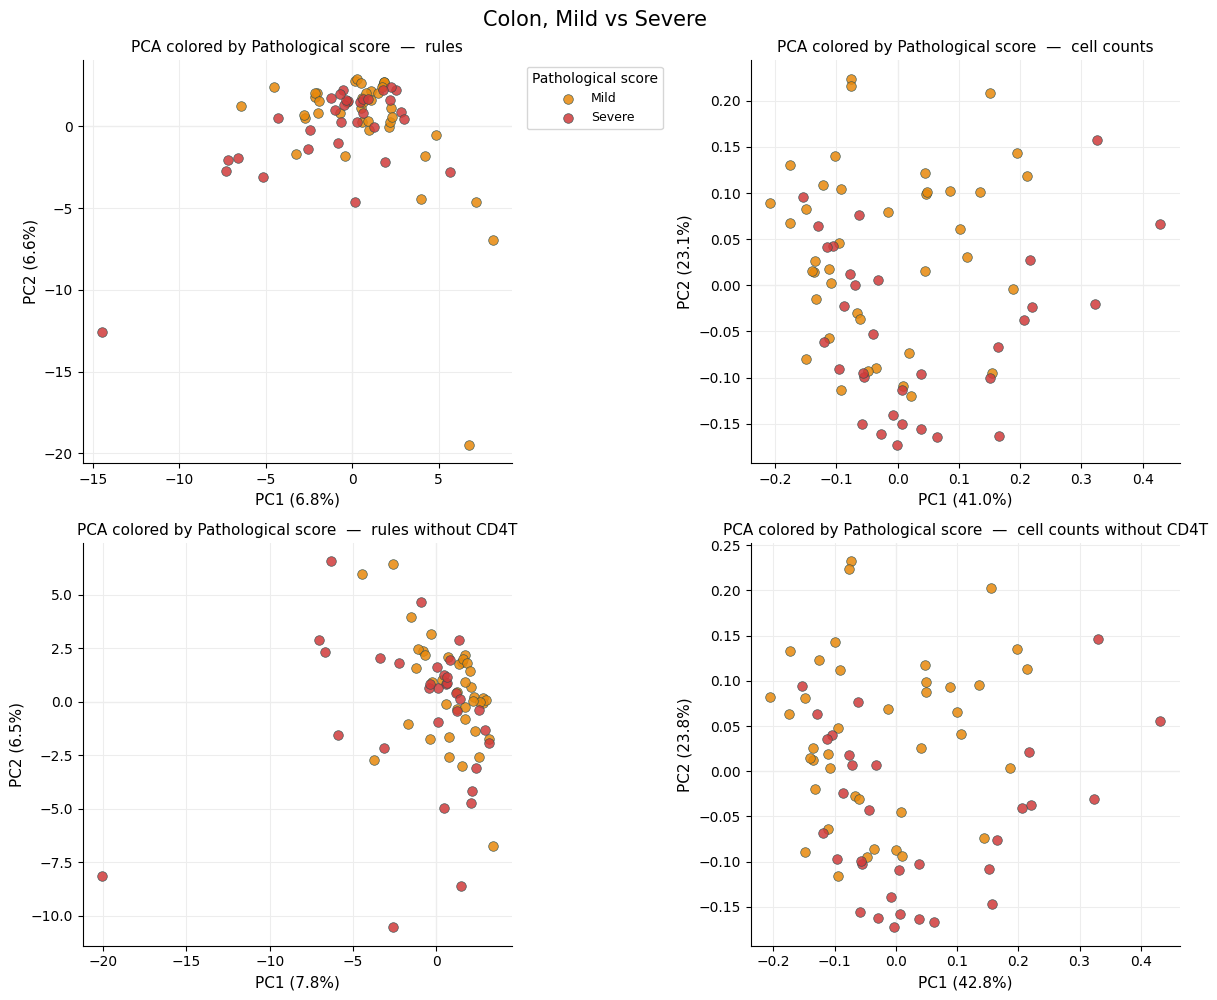

In [21]:
counts  = rs.composition_pca(data, ms_colon)
dropped = rs.leave_one_out(data, ms_colon)   # each row: rules, then cell counts

panel([[ms_colon, counts]] + dropped, save=None)


### 6b. Which cell types the components follow


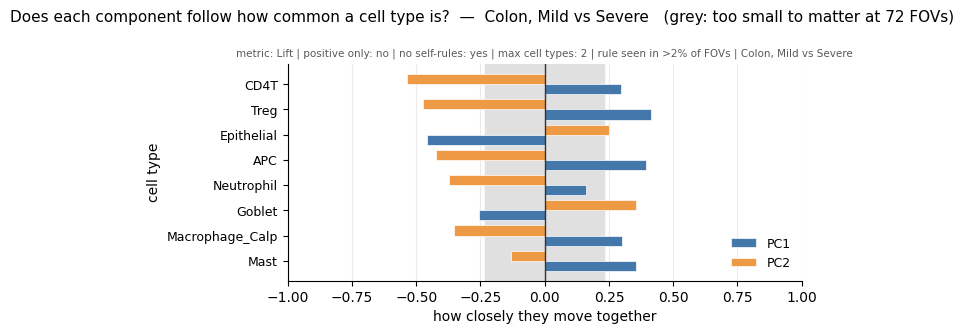

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


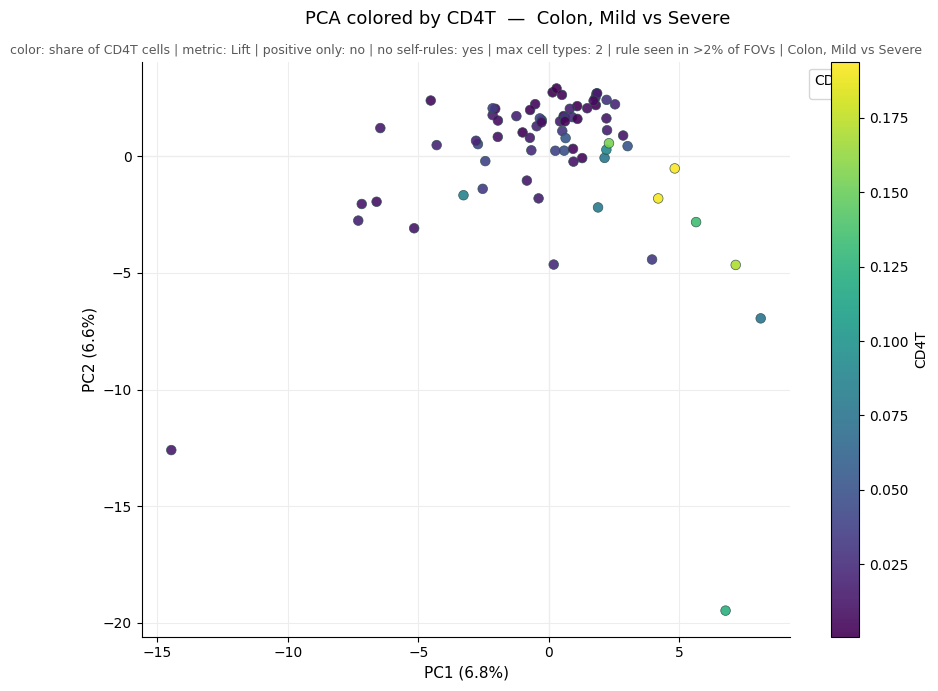

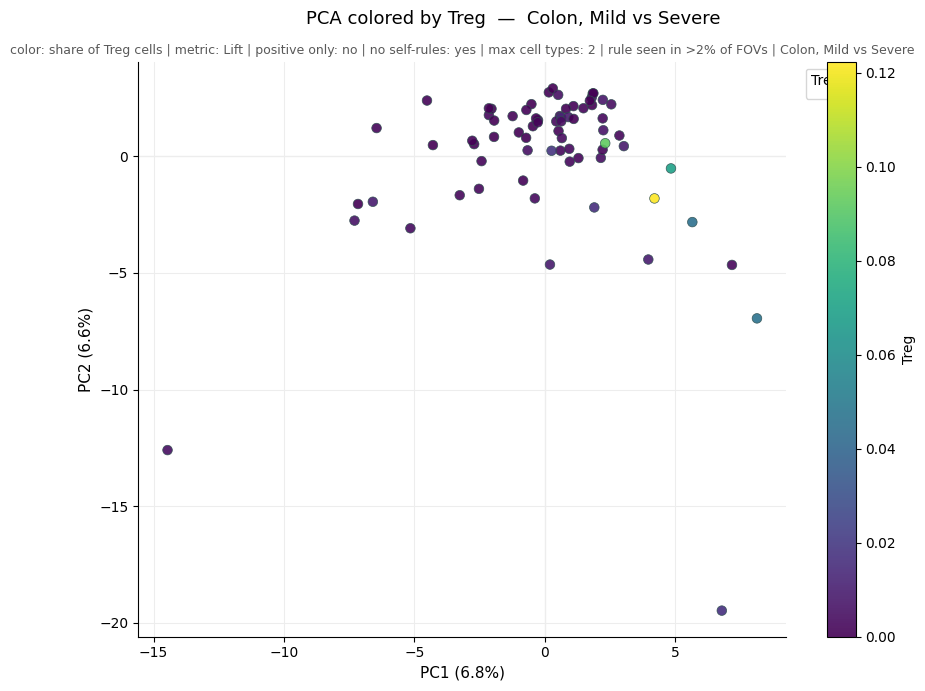

In [22]:
rs.abundance(data, ms_colon, save=False);


# 7. Duodenum, Mild vs Severe


In [23]:
ms_duodenum = rs.run(data,
                      stages=['Mild', 'Severe'], organs=['Duodenum'],
                      prefix='abund_ms_duodenum', diagnostics=False)


Duodenum, Mild vs Severe: 139 FOVs x 254 columns  |  PC1 5.2%  PC2 3.5%


### 7a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Duodenum, Mild vs Severe, cell counts: 139 FOVs x 32 columns  |  PC1 52.7%  PC2 22.8%
Duodenum, Mild vs Severe: 139 FOVs x 231 columns  |  PC1 5.6%  PC2 3.4%
Duodenum, Mild vs Severe, cell counts without Epithelial: 139 FOVs x 31 columns  |  PC1 45.6%  PC2 16.5%
Duodenum, Mild vs Severe: 139 FOVs x 221 columns  |  PC1 3.9%  PC2 3.7%
Duodenum, Mild vs Severe, cell counts without Goblet: 139 FOVs x 31 columns  |  PC1 52.5%  PC2 23.1%
Duodenum, Mild vs Severe: 138 FOVs x 219 columns  |  PC1 4.6%  PC2 3.5%
Duodenum, Mild vs Severe, cell counts without Macrophage: 139 FOVs x 31 columns  |  PC1 54.8%  PC2 22.7%


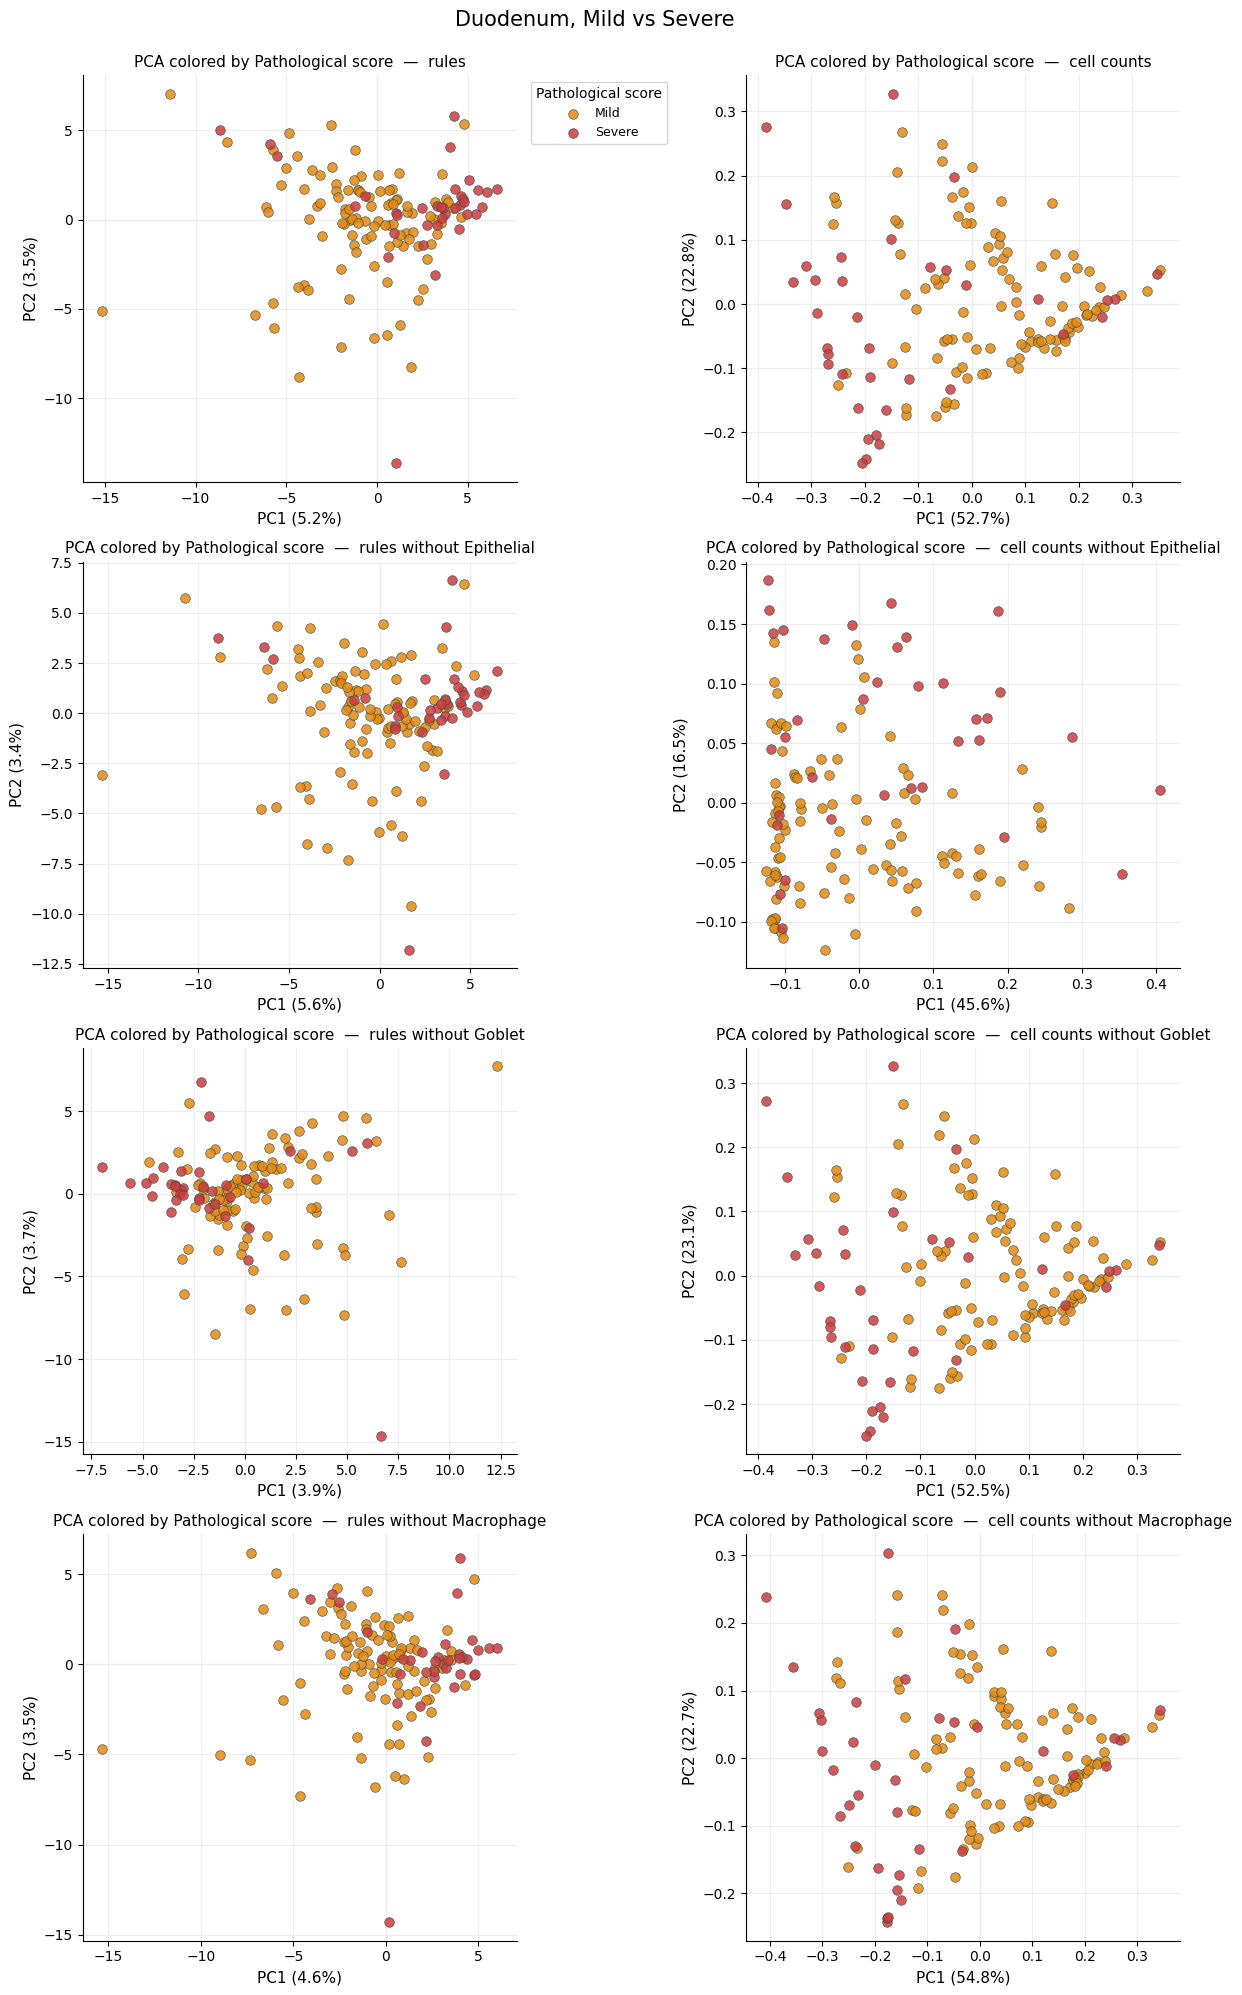

In [24]:
counts  = rs.composition_pca(data, ms_duodenum)
dropped = rs.leave_one_out(data, ms_duodenum)   # each row: rules, then cell counts

panel([[ms_duodenum, counts]] + dropped, save=None)


### 7b. Which cell types the components follow


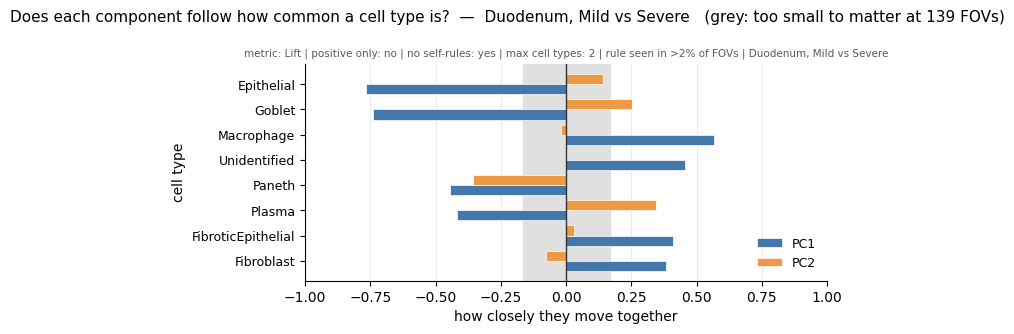

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:231: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


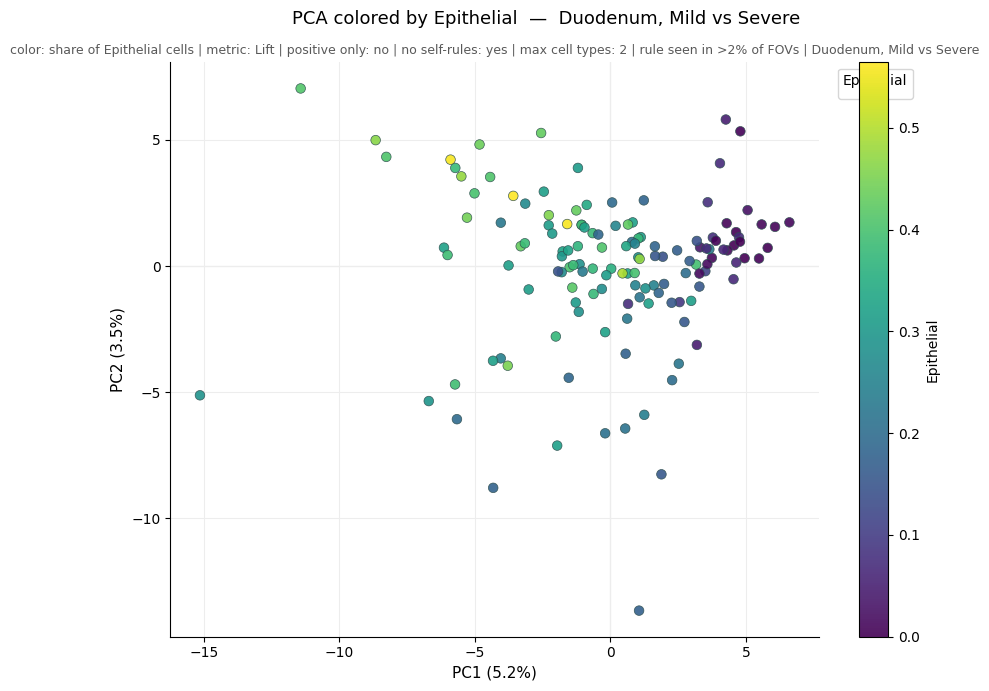

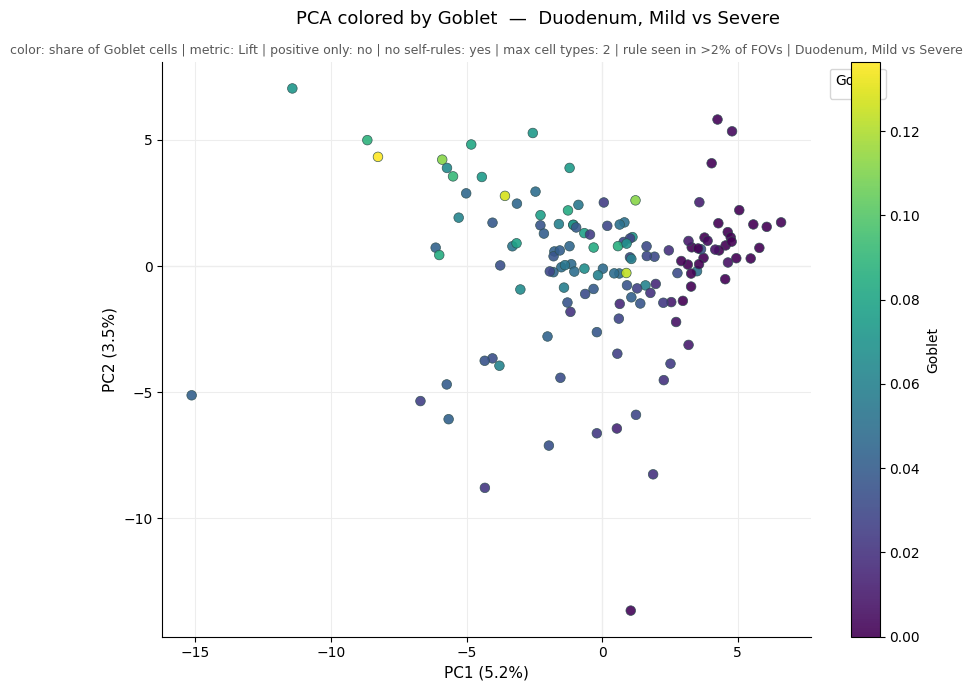

In [25]:
rs.abundance(data, ms_duodenum, save=False);


# 8. Same cells, different arrangement?

The FOVs are split in two by what they are made of - only the cell types this
PCA's components follow. If a group holds just one label, the cell counts alone
already separate those FOVs. If a group holds both, the rules can still be asked
whether they tell them apart with the composition held roughly fixed.


In [26]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def composition_groups(data, scope, label, save=None):
    """Split the FOVs in two by how much they hold of the cell types tied to this PCA.

    Clustering is on the square root of each share: raw shares let a cell type at 20%
    drown one at 3%, while standardising would give one at 0.1% an equal vote. The
    square root sits between the two.
    """
    cells = rs.linked_cells(data, scope)
    shares = data.fractions.reindex(scope.coords['FOV'])[cells]
    group = pd.Series(KMeans(n_clusters=2, n_init=10, random_state=0)
                      .fit_predict(np.sqrt(shares)), index=shares.index).map({0: 'A', 1: 'B'})
    table = pd.crosstab(group.rename('group'), scope.coords[label].values)
    rsv.plot_composition_split(table, shares.groupby(group).mean(), scope.label, label, save)
    return group, table

def composition_figures(data, scope, group, label, prefix):
    """The FOVs behind the groups: what each is made of, and every cell type at once."""
    cells = rs.linked_cells(data, scope)
    shares = data.fractions.reindex(scope.coords['FOV'])[cells] * 100
    order = shares.assign(_g=group).sort_values(['_g', cells[0]]).index

    frac = data.fractions.reindex(order)
    z = (frac - frac.mean()) / frac.std().replace(0, np.nan)

    # Cell types ordered by how far apart the two groups are, so the ones that tell
    # them apart gather at the two ends and the rest fall into the middle.
    per_group = z.groupby(group[order]).mean()
    difference = (per_group.loc['A'] - per_group.loc['B']).sort_values(ascending=False)

    labels = (group[order], scope.coords.set_index('FOV')[label][order])
    rsv.plot_composition_bars(shares.loc[order], labels, cells, scope.label,
                              f'{prefix}_group_bars')
    rsv.plot_composition_heatmap(z[difference.index], difference, labels, cells,
                                 scope.label, f'{prefix}_group_heatmap')


### 8a. All FOVs - do the composition groups line up with the organs?


saved summary_downloads\abund_all_groups.pdf


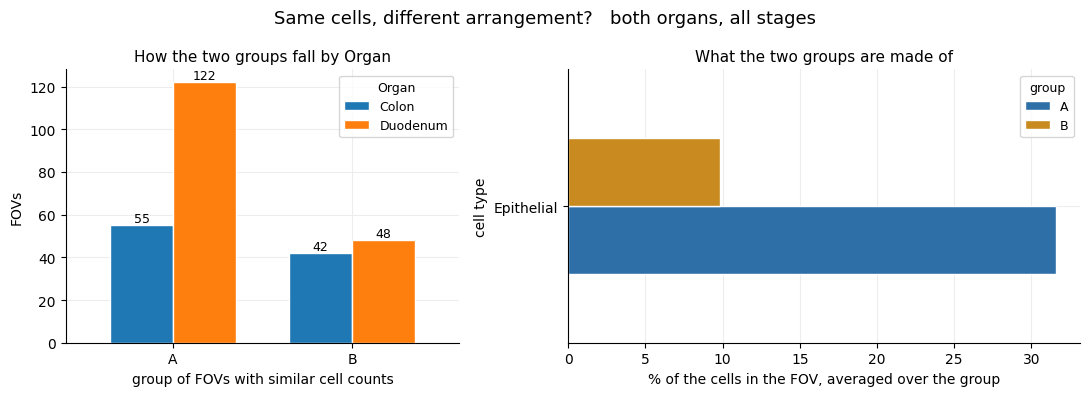

col_0,Colon,Duodenum
group,,
A,55,122
B,42,48


In [27]:
organ_groups, organ_table = composition_groups(
    data, all_fovs, 'Organ', save='abund_all_groups')
display(organ_table)


### 8b. Colon - do they line up with Control vs Severe?


saved summary_downloads\abund_cs_colon_groups.pdf


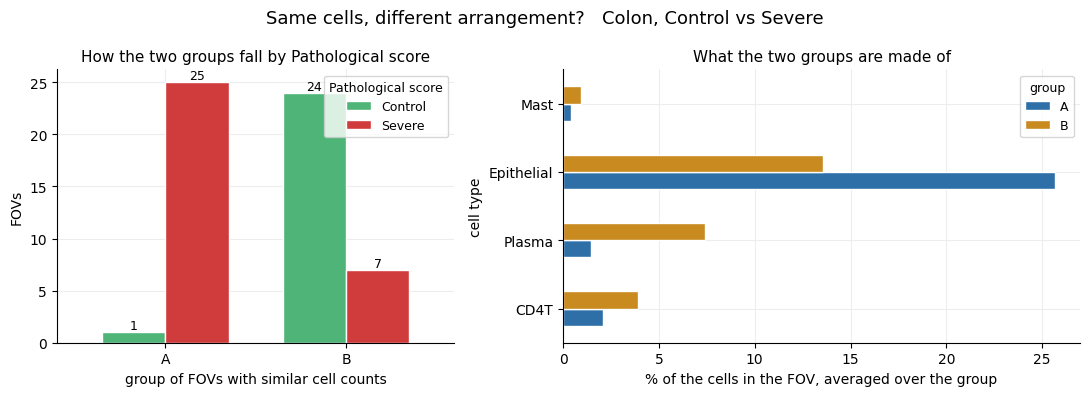

col_0,Control,Severe
group,,
A,1,25
B,24,7


In [28]:
colon_groups, colon_table = composition_groups(
    data, cs_colon, rs.SCORE_COL, save='abund_cs_colon_groups')
display(colon_table)


### 8c. Duodenum - do they line up with Control vs Severe?


saved summary_downloads\abund_cs_duodenum_groups.pdf


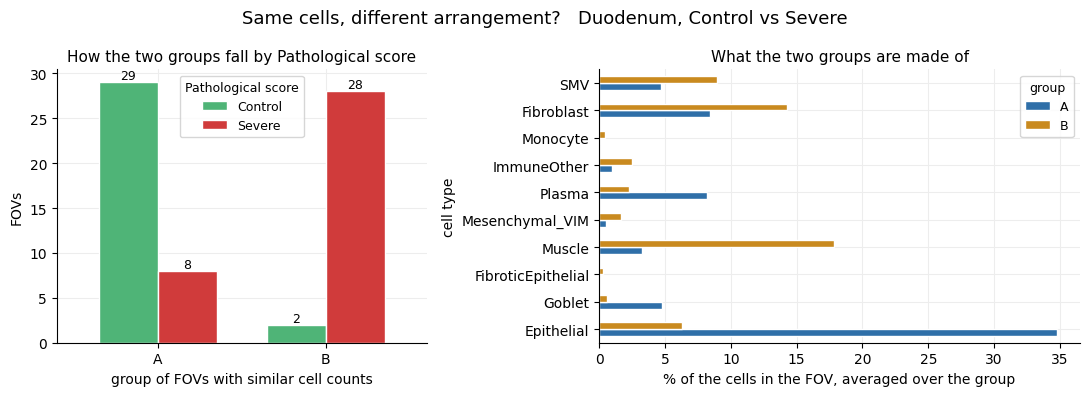

col_0,Control,Severe
group,,
A,29,8
B,2,28


In [29]:
duo_groups, duo_table = composition_groups(
    data, cs_duodenum, rs.SCORE_COL, save='abund_cs_duodenum_groups')
display(duo_table)


## The FOVs behind the groups

The bars show what each FOV is made of, the heatmap shows every cell type at
once. Both are sorted into the two groups, with the split we care about drawn
as a strip along the top.


saved summary_downloads\abund_all_group_bars.pdf


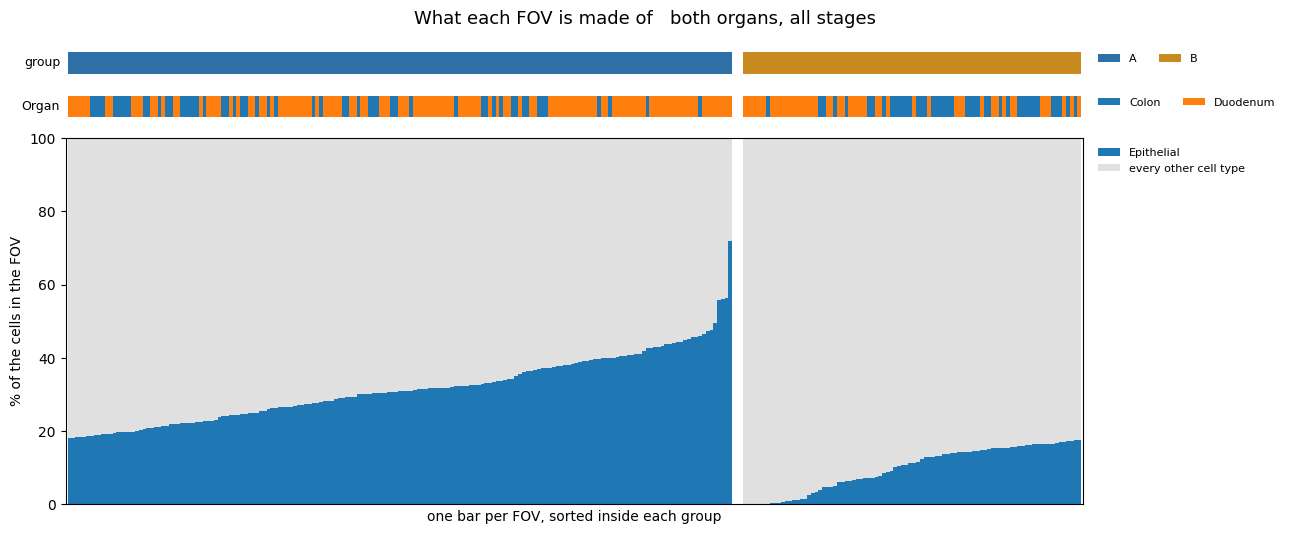

saved summary_downloads\abund_all_group_heatmap.pdf


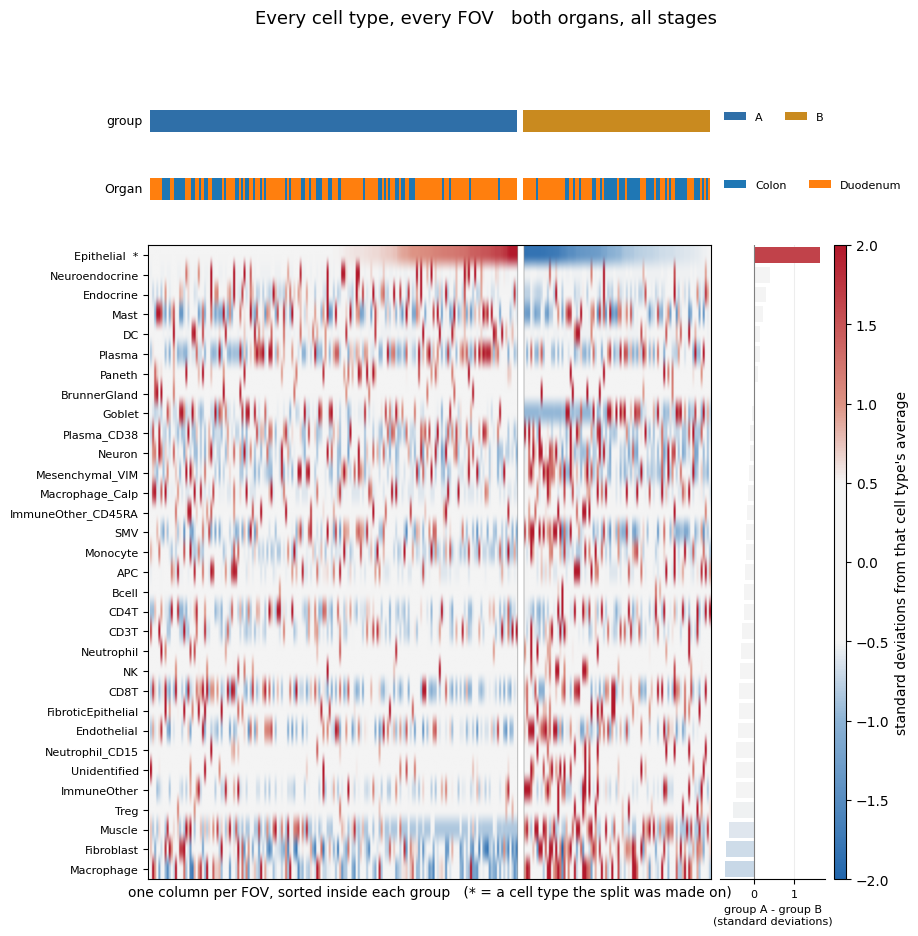

In [30]:
composition_figures(data, all_fovs, organ_groups, 'Organ', 'abund_all')


saved summary_downloads\abund_cs_colon_group_bars.pdf


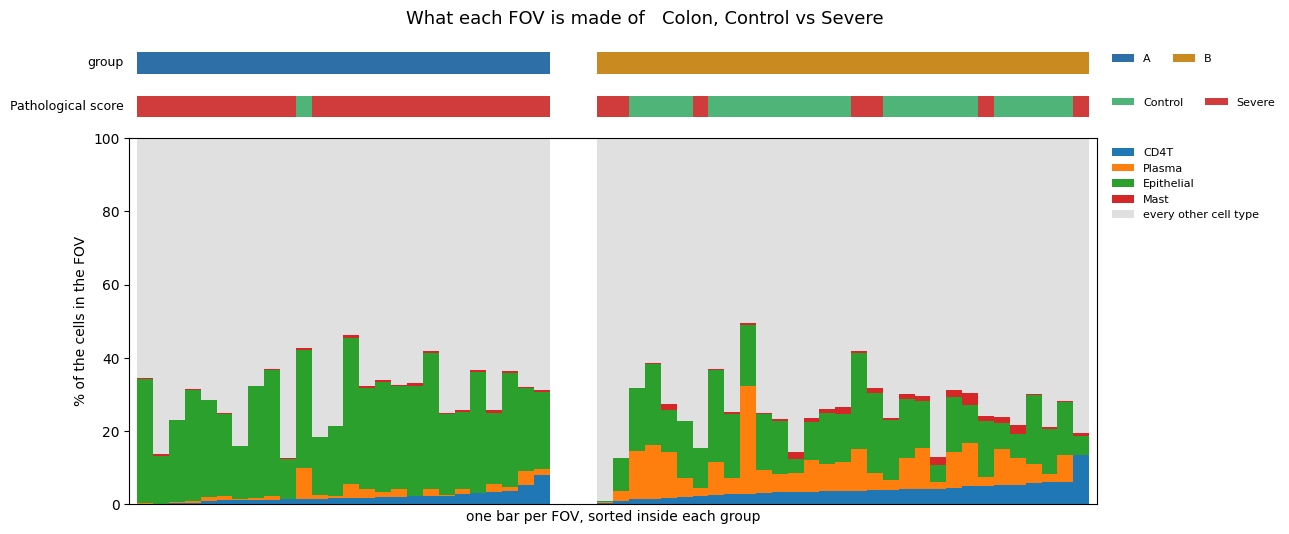

saved summary_downloads\abund_cs_colon_group_heatmap.pdf


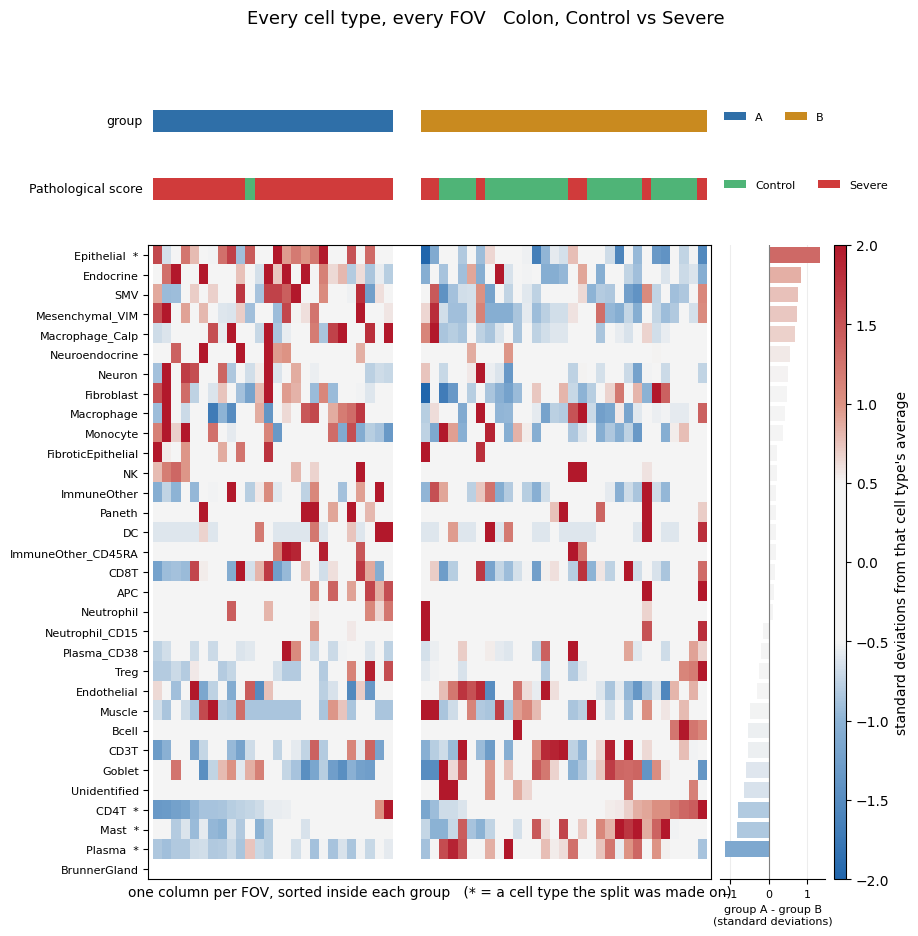

In [31]:
composition_figures(data, cs_colon, colon_groups, rs.SCORE_COL, 'abund_cs_colon')


saved summary_downloads\abund_cs_duodenum_group_bars.pdf


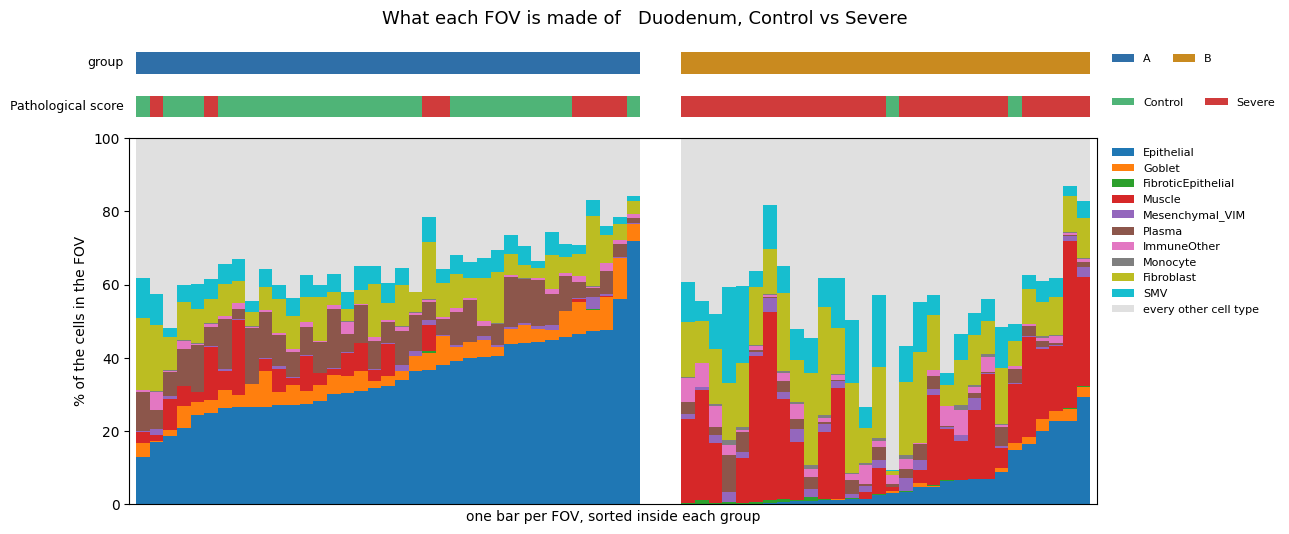

saved summary_downloads\abund_cs_duodenum_group_heatmap.pdf


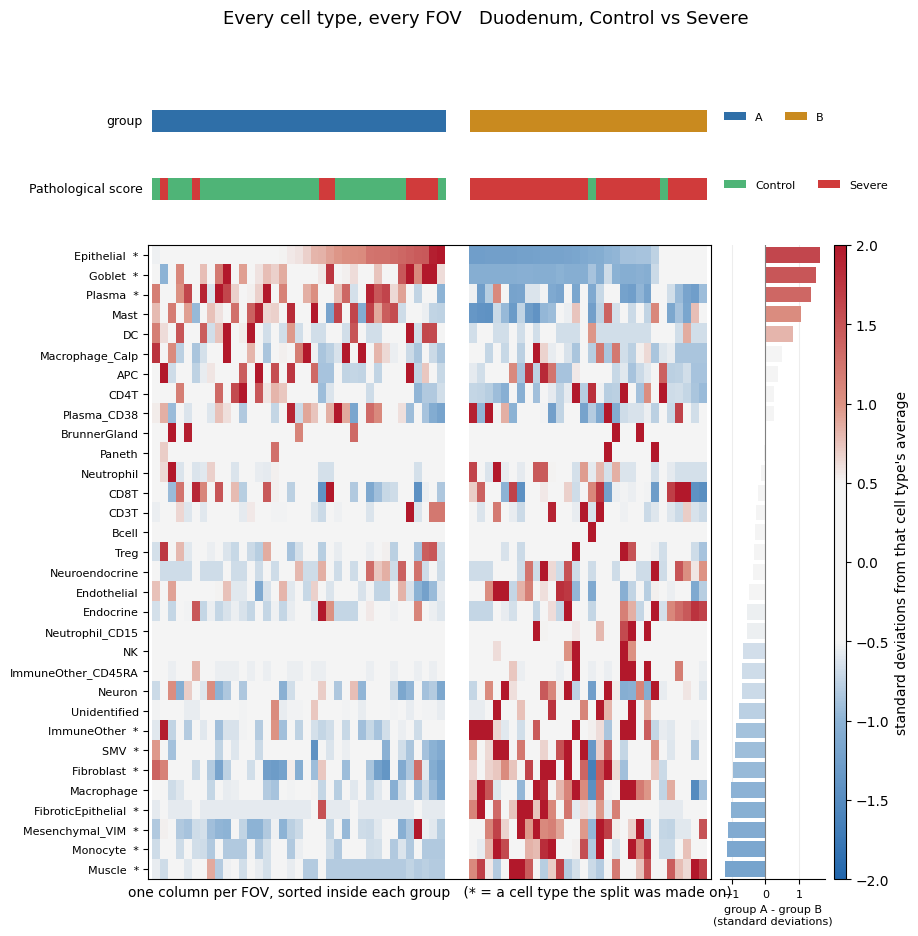

In [32]:
composition_figures(data, cs_duodenum, duo_groups, rs.SCORE_COL, 'abund_cs_duodenum')


# 9. Which rules exist, or how strong they are?

Most of the rule matrix is the fill value - a typical rule fires in only a few
percent of the FOVs - so the PCA may be reading which rules exist rather than
how strong they are. Three matrices side by side settle it: the lift values, the
same rules as 1/0, and whether the FOV had enough of both cell types for the rule
to be found at all. The last one knows nothing about where the cells sit.


### 9a. All FOVs, by organ


both organs, all stages, which rules fired: 267 FOVs x 220 columns  |  PC1 5.3%  PC2 4.2%
both organs, all stages, which rules could fire: 267 FOVs x 220 columns  |  PC1 15.0%  PC2 9.0%
saved summary_downloads\abund_all_presence.pdf


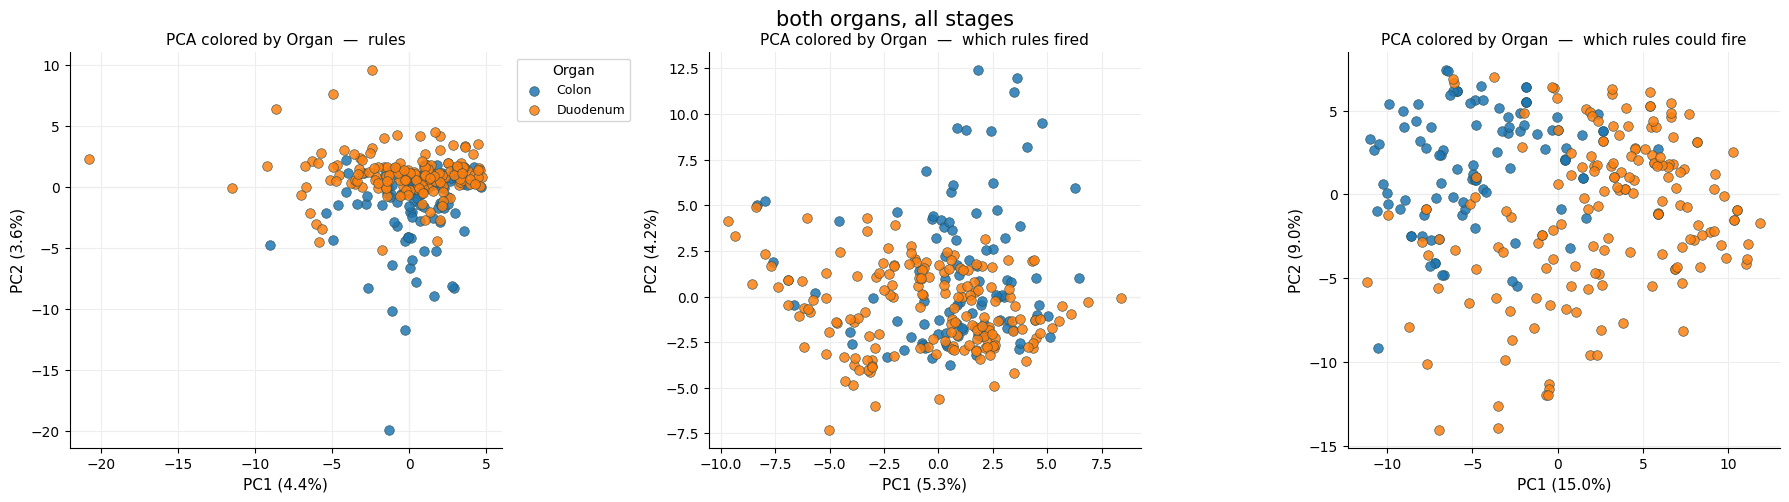

In [33]:
fired, possible = rs.presence_matrices(data, all_fovs)

panel([[all_fovs, fired, possible]], color_by='Organ', save='abund_all_presence')


### 9b. Colon, Control vs Severe


Colon, Control vs Severe, which rules fired: 57 FOVs x 177 columns  |  PC1 9.7%  PC2 7.6%
Colon, Control vs Severe, which rules could fire: 57 FOVs x 168 columns  |  PC1 16.7%  PC2 12.4%
saved summary_downloads\abund_cs_colon_presence.pdf


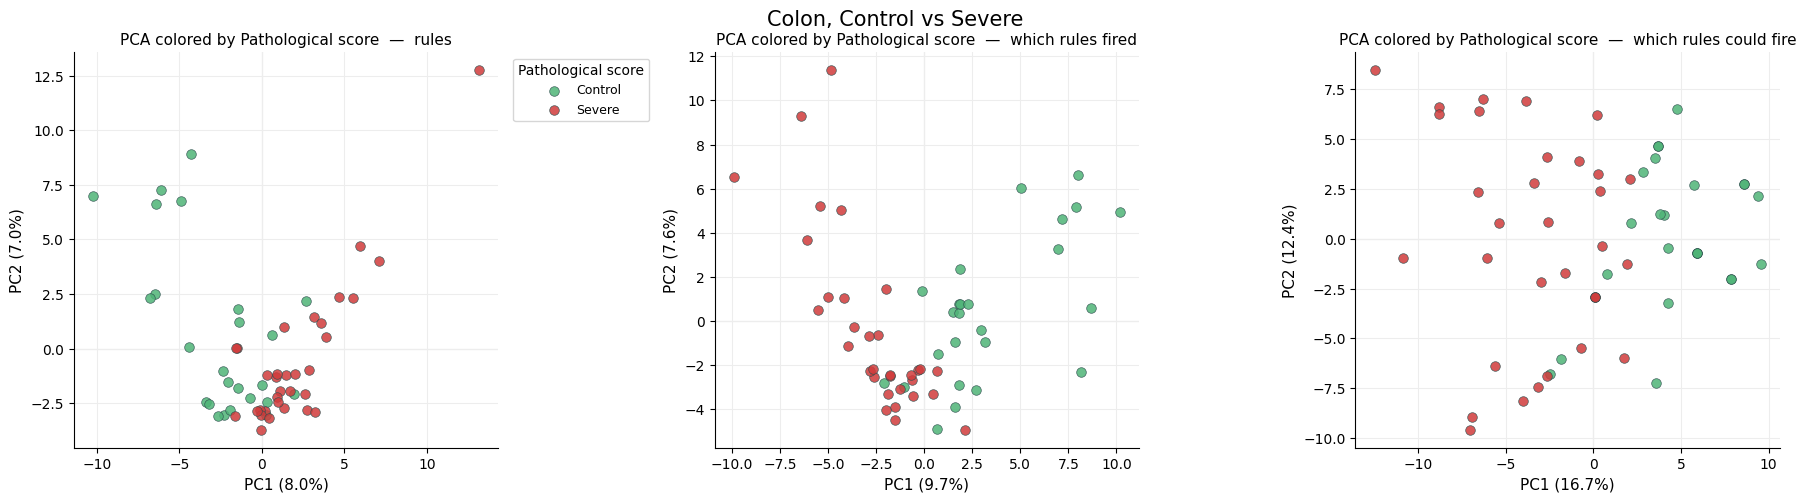

In [34]:
fired, possible = rs.presence_matrices(data, cs_colon)

panel([[cs_colon, fired, possible]], save='abund_cs_colon_presence')


### 9c. Duodenum, Control vs Severe


Duodenum, Control vs Severe, which rules fired: 67 FOVs x 227 columns  |  PC1 8.2%  PC2 5.4%
Duodenum, Control vs Severe, which rules could fire: 67 FOVs x 226 columns  |  PC1 16.9%  PC2 12.8%
saved summary_downloads\abund_cs_duodenum_presence.pdf


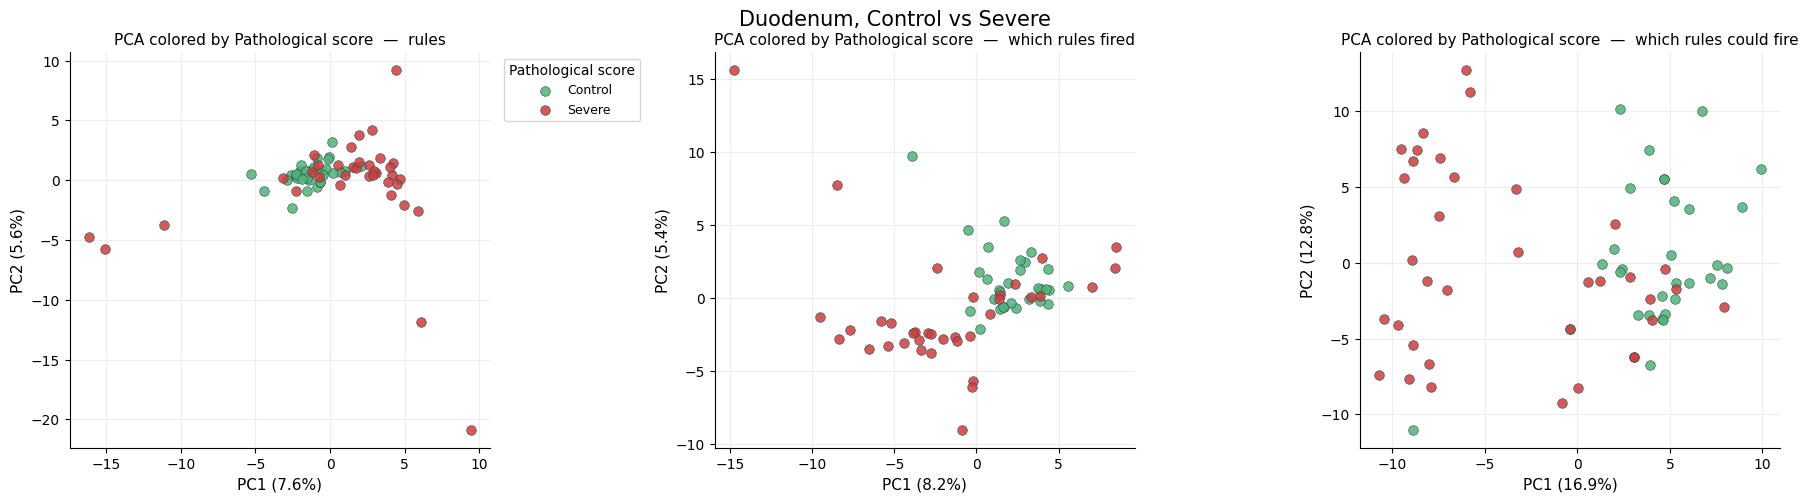

: 

In [ ]:
fired, possible = rs.presence_matrices(data, cs_duodenum)

panel([[cs_duodenum, fired, possible]], save='abund_cs_duodenum_presence')
